# Performing Data Analysis and predicting the price of Houses using Advanced regression Techniques

1. Importing the dataset

In [2]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
filepath = r'C:\Users\hp\Downloads\house-prices-advanced-regression-techniques\train.csv'
df = pd.read_csv(filepath)
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

In [6]:
df.describe(include='all')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
count,1460.000000,1460.000000,1460,1201.000000,1460.000000,1460,91,1460,1460,1460,...,1460.000000,7,281,54,1460.000000,1460.000000,1460.000000,1460,1460,1460.000000
unique,NaN,NaN,5,NaN,NaN,2,2,4,4,2,...,NaN,3,4,4,NaN,NaN,NaN,9,6,NaN
top,NaN,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,AllPub,...,NaN,Gd,MnPrv,Shed,NaN,NaN,NaN,WD,Normal,NaN
freq,NaN,NaN,1151,NaN,NaN,1454,50,925,1311,1459,...,NaN,3,157,49,NaN,NaN,NaN,1267,1198,NaN
mean,730.500000,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN,NaN,NaN,...,2.758904,NaN,NaN,NaN,43.489041,6.321918,2007.815753,NaN,NaN,180921.195890
std,421.610009,42.300571,NaN,24.284752,9981.264932,NaN,NaN,NaN,NaN,NaN,...,40.177307,NaN,NaN,NaN,496.123024,2.703626,1.328095,NaN,NaN,79442.502883
min,1.000000,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,1.000000,2006.000000,NaN,NaN,34900.000000
25%,365.750000,20.000000,NaN,59.000000,7553.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,5.000000,2007.000000,NaN,NaN,129975.000000
50%,730.500000,50.000000,NaN,69.000000,9478.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,6.000000,2008.000000,NaN,NaN,163000.000000
75%,1095.250000,70.000000,NaN,80.000000,11601.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,8.000000,2009.000000,NaN,NaN,214000.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [8]:
missing_values = df.isnull()
for columns in missing_values.columns.values.tolist():
    print(missing_values[columns].value_counts())
    print(' ')

Id
False    1460
Name: count, dtype: int64
 
MSSubClass
False    1460
Name: count, dtype: int64
 
MSZoning
False    1460
Name: count, dtype: int64
 
LotFrontage
False    1201
True      259
Name: count, dtype: int64
 
LotArea
False    1460
Name: count, dtype: int64
 
Street
False    1460
Name: count, dtype: int64
 
Alley
True     1369
False      91
Name: count, dtype: int64
 
LotShape
False    1460
Name: count, dtype: int64
 
LandContour
False    1460
Name: count, dtype: int64
 
Utilities
False    1460
Name: count, dtype: int64
 
LotConfig
False    1460
Name: count, dtype: int64
 
LandSlope
False    1460
Name: count, dtype: int64
 
Neighborhood
False    1460
Name: count, dtype: int64
 
Condition1
False    1460
Name: count, dtype: int64
 
Condition2
False    1460
Name: count, dtype: int64
 
BldgType
False    1460
Name: count, dtype: int64
 
HouseStyle
False    1460
Name: count, dtype: int64
 
OverallQual
False    1460
Name: count, dtype: int64
 
OverallCond
False    1460
Name: count, dty

## Handle Missing values in columns

1. Handling Lot frontage missing values by replacing null values with average of all  the values

In [9]:
average_value = df['LotFrontage'].mean()
df['LotFrontage'].replace(np.NaN, average_value, inplace = True)

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\1480253756.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LotFrontage'].replace(np.NaN, average_value, inplace = True)


2. To handle missing values in Alley column, we first replace the NaN values with None and then find the avg price by grouping the alley column. 

In [10]:
df['Alley'].replace(np.NaN, 'None', inplace= True)
df_new = df.groupby(['Alley'])['SalePrice'].mean()
df_new

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\159721582.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Alley'].replace(np.NaN, 'None', inplace= True)


Alley
Grvl    122219.080000
None    183452.131483
Pave    168000.585366
Name: SalePrice, dtype: float64

we found a significant difference in prices between the None and other alley types. Therefore, it means that None values are also affecting prices of the household. Hence we will not drop them off the database.

3. Now we will handle missing values of MasVnrType column.  We tried to find the price with different styles and they have a significant price difference. Therefore we have just replace missing values with string __none__

In [11]:
df['MasVnrType'].replace(np.NaN, 'None', inplace= True)
df1 = df.groupby(['MasVnrType'])['SalePrice'].mean()
df1

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\1375885276.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MasVnrType'].replace(np.NaN, 'None', inplace= True)


MasVnrType
BrkCmn     146318.066667
BrkFace    204691.871910
None       156958.243119
Stone      265583.625000
Name: SalePrice, dtype: float64

- Checking if missing values in MasVnrArea is for other MasVnrType or for none values to replace them with 0.0

In [12]:
df.loc[df['MasVnrArea'].isna(), ['MasVnrType', 'MasVnrArea']].head(8)

,MasVnrType,MasVnrArea
234,None,NaN
529,None,NaN
650,None,NaN
936,None,NaN
973,None,NaN
977,None,NaN
1243,None,NaN
1278,None,NaN


- Replaced values with 0 as masVnrtype was none

In [13]:
df['MasVnrArea'].replace(np.NaN, 0, inplace = True)

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\1352840627.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MasVnrArea'].replace(np.NaN, 0, inplace = True)


3. Now we will handle missing values related to __Basement__ fields.

In [14]:
df['BsmtQual'].replace(np.NaN, 'None', inplace = True)

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\1129552215.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['BsmtQual'].replace(np.NaN, 'None', inplace = True)


In [15]:
df_group = df.groupby('BsmtQual')['SalePrice'].mean()
df_group

BsmtQual
Ex      327041.041322
Fa      115692.028571
Gd      202688.478964
None    105652.891892
TA      140759.818182
Name: SalePrice, dtype: float64

- It can be inferred from the data that none values have significant price difference from other catgeories. Therefore we cannot narrow down the possiblity of 'none' values affecting price.

#### Till now, it is observed that the fields which have missing values are affecting the price. Even missing values have significant different from other values. Moreover, missing values indicate only that the particular amenity is not in the house. Hence we will fill all null values with none in 'object' data type columns and 0 in 'numeric' data type columns


In [16]:
obj_col = df.select_dtypes(include = ['object']).columns
df[obj_col] = df[obj_col].fillna('None')

num_col = df.select_dtypes(exclude = ['object']).columns
df[num_col] = df[num_col].fillna(0)

Since id column has no relation with price. we are dropping it.

In [17]:
df.drop('Id', axis = 1, inplace = True)

In [18]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,...,0,None,None,None,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,...,0,None,None,None,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,...,0,None,None,None,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,...,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,...,0,None,None,None,0,12,2008,WD,Normal,250000


## Data formatting

In [19]:
df['GarageYrBlt'].astype(int)

0       2003
1       1976
2       2001
3       1998
4       2000
        ... 
1455    1999
1456    1978
1457    1941
1458    1950
1459    1965
Name: GarageYrBlt, Length: 1460, dtype: int32

# Exploratory Data Analysis

<Axes: xlabel='SalePrice', ylabel='Count'>

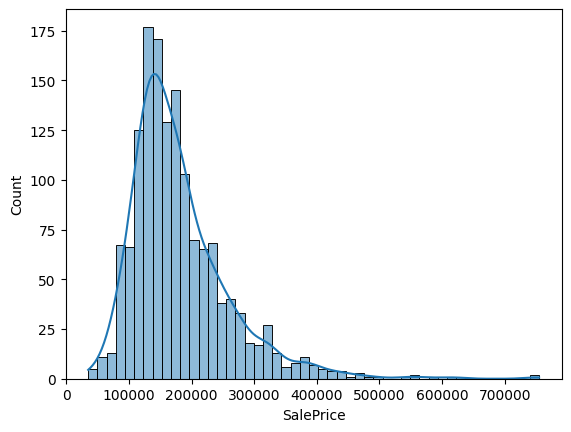

In [20]:
sns.histplot(df['SalePrice'], kde = True)

<Axes: xlabel='Street', ylabel='Log_SalePrice'>

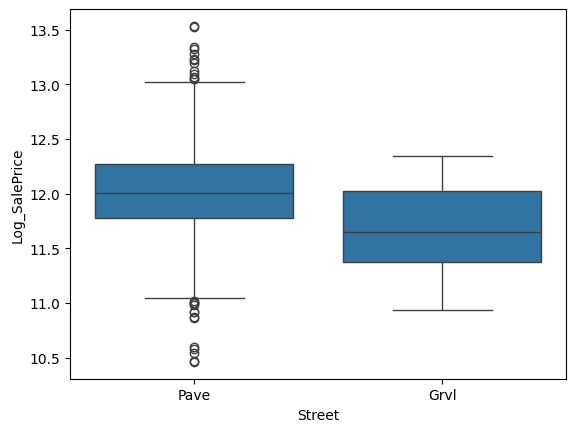

In [21]:
df['Log_SalePrice'] = np.log1p(df['SalePrice'])
sns.boxplot(x = df['Street'], y = df['Log_SalePrice'])

<Axes: >

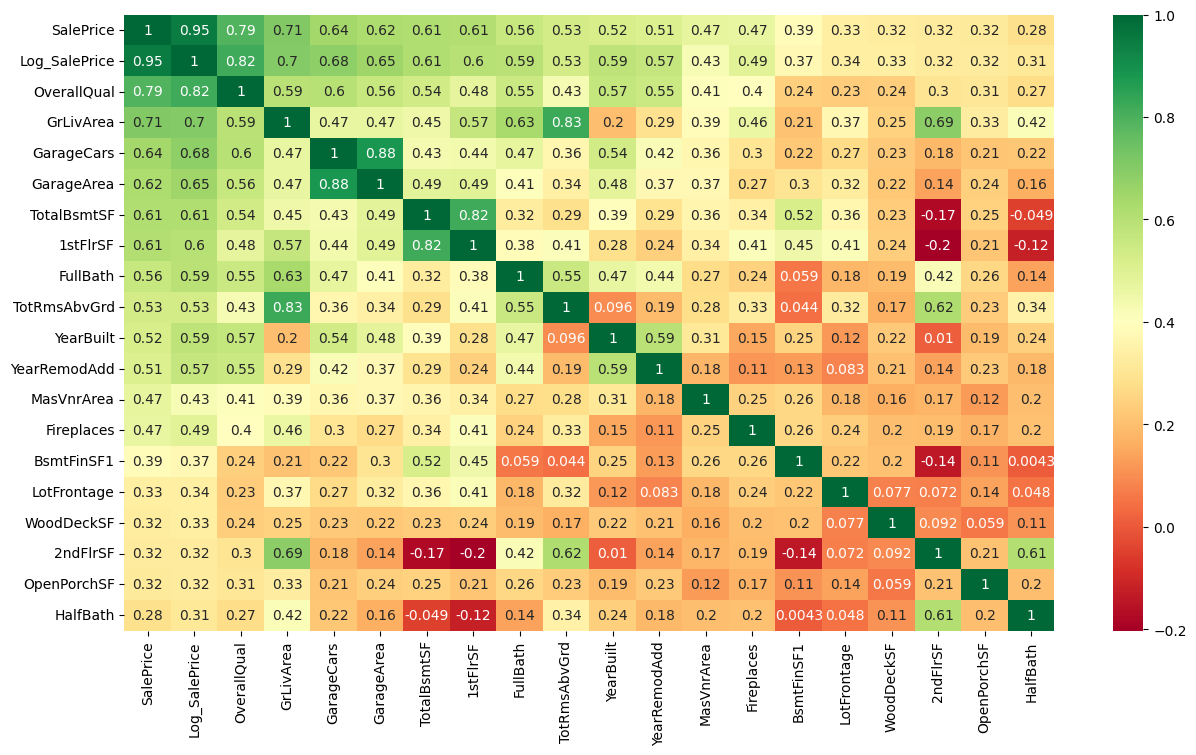

In [22]:
cols = df.corr(numeric_only = True)['SalePrice'].sort_values(ascending=False).head(20).index #checking correlation with sale price
plt.figure(figsize=(15, 8))
sns.heatmap(df[cols].corr(), annot=True, cmap='RdYlGn')# checking collinearity

### Handling Categorical variables

Now, we will handle categorical variables by analyzing their boxplots. If the categories have same value it is most likely not affecting sale price.

In [23]:
df['Street'].value_counts()

Street
Pave    1454
Grvl       6
Name: count, dtype: int64

we have observed that dataset is more shifted to pave street. So there is no benefit of using it for price prediction as it is not spread. Same thing happens for alley. The dataset is skewed to no alley.

In [24]:
df.drop(['Street', 'Alley'], inplace = True, axis = 1)

<Axes: xlabel='Utilities', ylabel='SalePrice'>

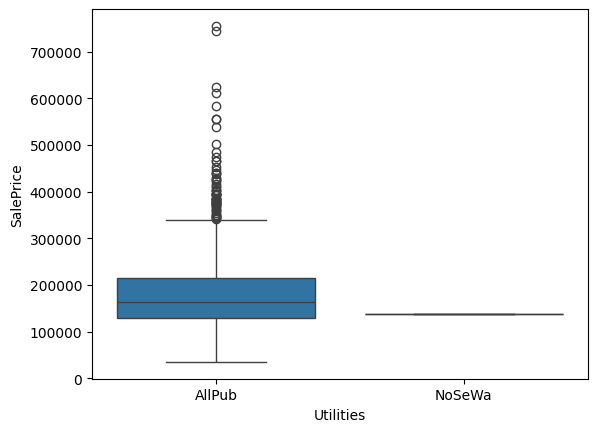

In [25]:
sns.boxplot(x = df['Utilities'], y = df['SalePrice'])

Since utilities have all public facilities, we will try to count the values of categories in utilities column.

In [26]:
df['Utilities'].value_counts()

Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

In [27]:
df.drop('Utilities', axis =1, inplace = True)

No affect of utilities on sale price as nearly all house are having all basic utilities of electricity, gas, power and water

In [28]:
df['Neighborhood'].value_counts()

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

We have observed that the dataset is evenly distributed in neighbourhood column. So this feature may affect the price of houses.

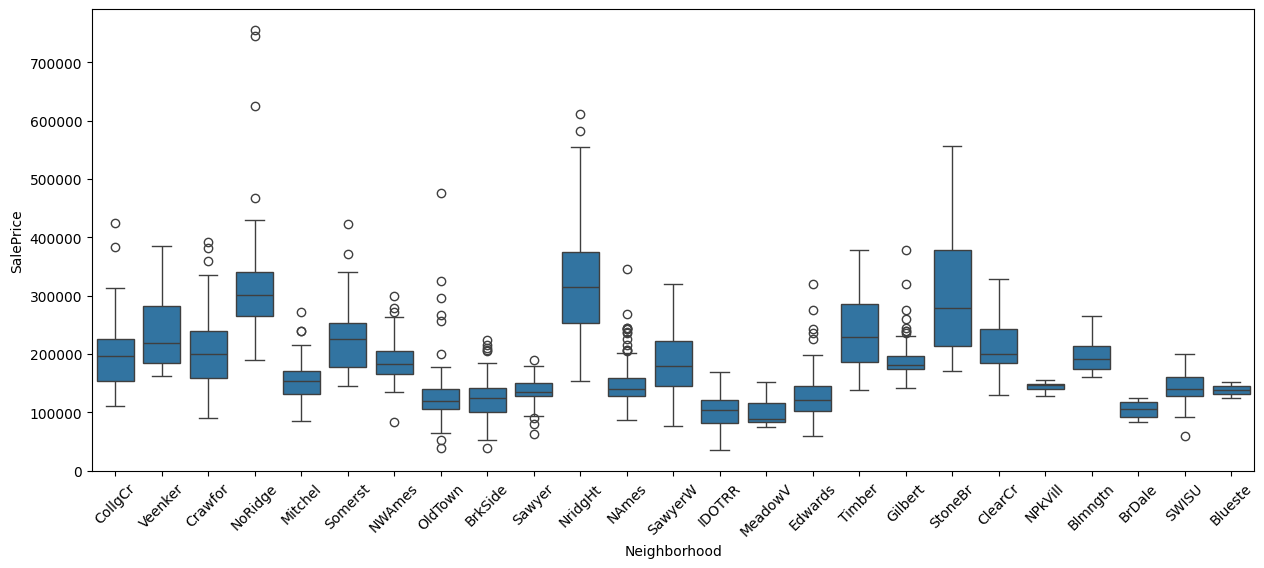

In [29]:
plt.figure(figsize=(15,6))
sns.boxplot(x='Neighborhood', y='SalePrice', data=df)
plt.xticks(rotation=45) # Rotates labels so they don't overlap
plt.show()

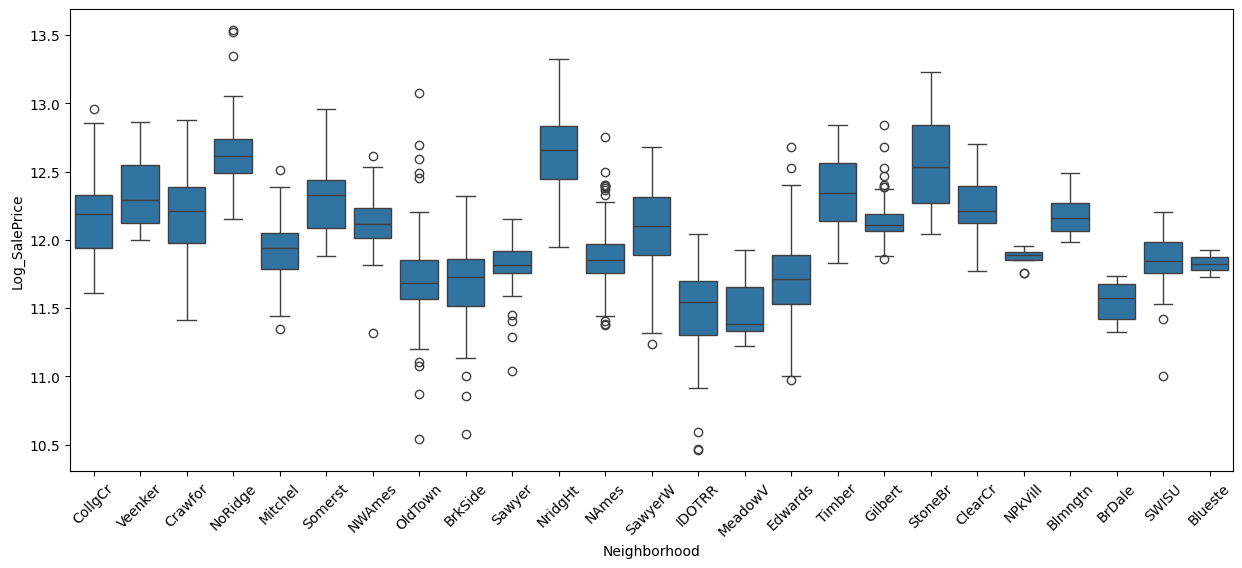

In [30]:
plt.figure(figsize = (15,6))
sns.boxplot(x= df['Neighborhood'], y = df['Log_SalePrice'])
plt.xticks(rotation = 45)
plt.show()

So here we have observed that the boxplot has no same median over all the categories and moreover in some parts of the boxplot it follows step order. so we conclude that this feature may affect the price of the housing dataset

In [31]:
df['LotShape'].value_counts()

LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

<Axes: xlabel='LotShape', ylabel='SalePrice'>

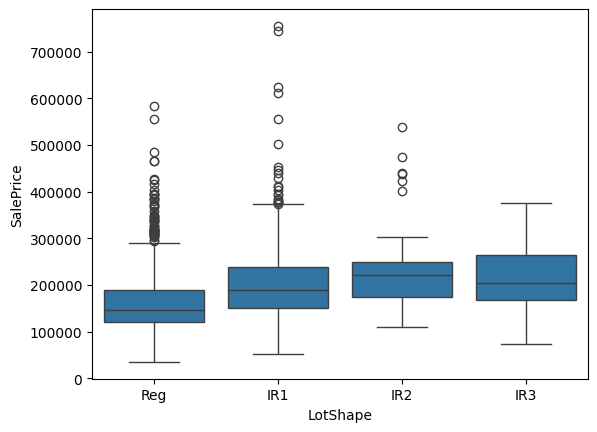

In [32]:
sns.boxplot(x = 'LotShape', y = 'SalePrice', data = df)

The distribution across categories seems to be overlapping, so it may not affect price. hence we can drop the lot shape.


In [33]:
df.drop('LotShape', axis = 1, inplace = True)
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,Log_SalePrice
0,60,RL,65.0,8450,Lvl,Inside,Gtl,CollgCr,Norm,Norm,...,None,None,None,0,2,2008,WD,Normal,208500,12.247699
1,20,RL,80.0,9600,Lvl,FR2,Gtl,Veenker,Feedr,Norm,...,None,None,None,0,5,2007,WD,Normal,181500,12.109016
2,60,RL,68.0,11250,Lvl,Inside,Gtl,CollgCr,Norm,Norm,...,None,None,None,0,9,2008,WD,Normal,223500,12.317171
3,70,RL,60.0,9550,Lvl,Corner,Gtl,Crawfor,Norm,Norm,...,None,None,None,0,2,2006,WD,Abnorml,140000,11.849405
4,60,RL,84.0,14260,Lvl,FR2,Gtl,NoRidge,Norm,Norm,...,None,None,None,0,12,2008,WD,Normal,250000,12.429220


In [34]:
df['LandContour'].value_counts()

LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64

Data is not evenly distributed in landContour attribute. so it will be dropped from the database.

In [35]:
df.drop('LandContour', axis = 1, inplace = True)

In [36]:
df['LotConfig'].value_counts()

LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64

<Axes: xlabel='LotConfig', ylabel='SalePrice'>

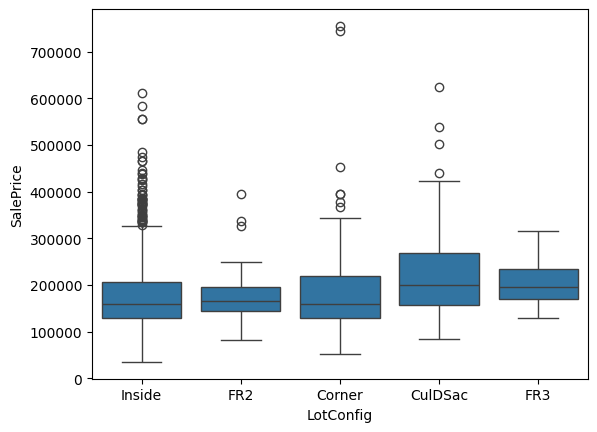

In [37]:
sns.boxplot(x = df['LotConfig'], y = df['SalePrice'])

This feature is not helping our model to distinguish between the housing data. So we will drop it

In [38]:
df.drop('LotConfig', axis = 1, inplace = True)

In [39]:
df['LandSlope'].value_counts()

LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64

Since the data is skewed to gentle slope. WE will drop this feature.

In [40]:
df.drop('LandSlope', axis = 1, inplace = True)
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,Log_SalePrice
0,60,RL,65.0,8450,CollgCr,Norm,Norm,1Fam,2Story,7,...,None,None,None,0,2,2008,WD,Normal,208500,12.247699
1,20,RL,80.0,9600,Veenker,Feedr,Norm,1Fam,1Story,6,...,None,None,None,0,5,2007,WD,Normal,181500,12.109016
2,60,RL,68.0,11250,CollgCr,Norm,Norm,1Fam,2Story,7,...,None,None,None,0,9,2008,WD,Normal,223500,12.317171
3,70,RL,60.0,9550,Crawfor,Norm,Norm,1Fam,2Story,7,...,None,None,None,0,2,2006,WD,Abnorml,140000,11.849405
4,60,RL,84.0,14260,NoRidge,Norm,Norm,1Fam,2Story,8,...,None,None,None,0,12,2008,WD,Normal,250000,12.429220


In [41]:
df['Condition1'].value_counts()

Condition1
Norm      1260
Feedr       81
Artery      48
RRAn        26
PosN        19
RRAe        11
PosA         8
RRNn         5
RRNe         2
Name: count, dtype: int64

<Axes: xlabel='Condition1', ylabel='SalePrice'>

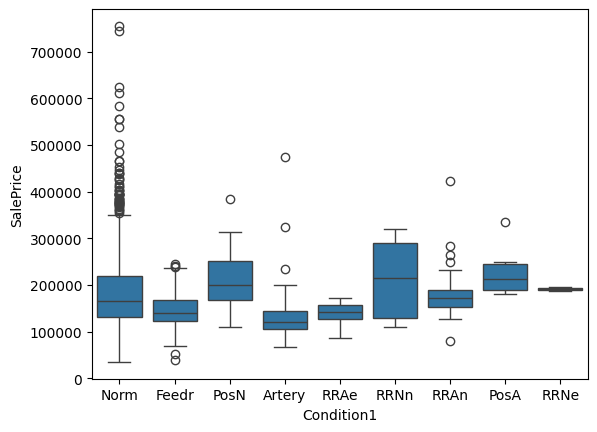

In [42]:
sns.boxplot(x = df['Condition1'], y = df['SalePrice'])

In [43]:
df['Condition2'].value_counts()

Condition2
Norm      1445
Feedr        6
Artery       2
RRNn         2
PosN         2
PosA         1
RRAn         1
RRAe         1
Name: count, dtype: int64

Both condition 1 and 2 have no effect on saleprice as most of the data is skewed to normal feature.


In [44]:
df.drop(['Condition1', 'Condition2'], axis = 1, inplace = True)

In [45]:
df['BldgType'].value_counts()

BldgType
1Fam      1220
TwnhsE     114
Duplex      52
Twnhs       43
2fmCon      31
Name: count, dtype: int64

<Axes: xlabel='BldgType', ylabel='SalePrice'>

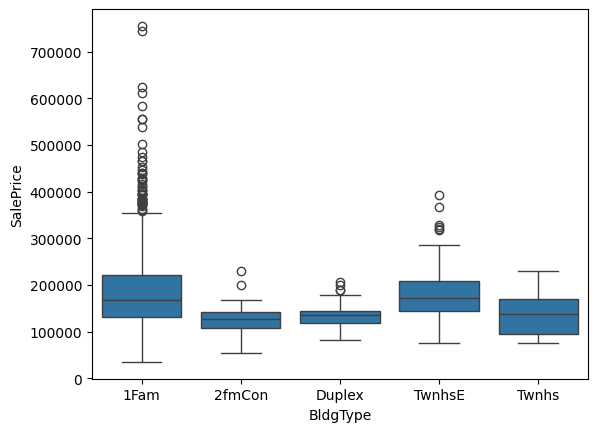

In [46]:
sns.boxplot(x = df['BldgType'], y = df['SalePrice'])

In [47]:
df.drop('BldgType', axis = 1, inplace = True)

In [48]:
df['HouseStyle'].value_counts()

HouseStyle
1Story    726
2Story    445
1.5Fin    154
SLvl       65
SFoyer     37
1.5Unf     14
2.5Unf     11
2.5Fin      8
Name: count, dtype: int64

<Axes: xlabel='HouseStyle', ylabel='SalePrice'>

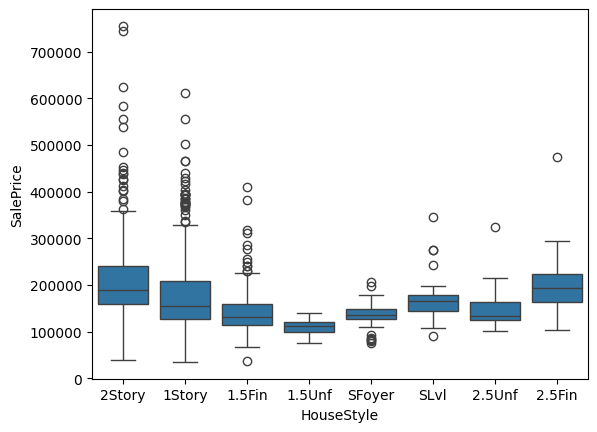

In [49]:
sns.boxplot(x = df['HouseStyle'], y = df['SalePrice'])

In [50]:
df['OverallQual'].value_counts()

OverallQual
5     397
6     374
7     319
8     168
4     116
9      43
3      20
10     18
2       3
1       2
Name: count, dtype: int64

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

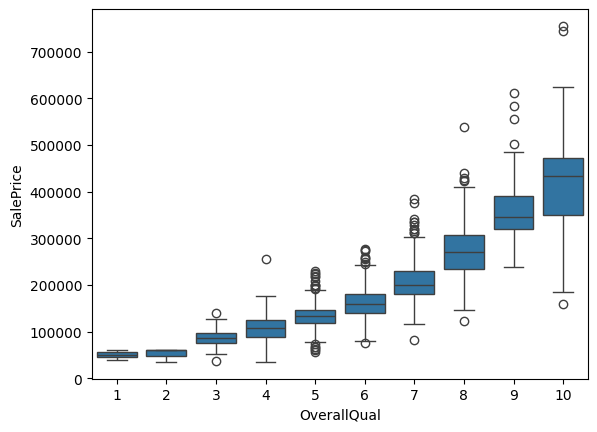

In [51]:
sns.boxplot(x = 'OverallQual', y = 'SalePrice', data = df)

Since the boxplot shows the staircase effect and also the data is evenly distributes. we will keep this attribute

In [52]:
df['OverallCond'].value_counts()

OverallCond
5    821
6    252
7    205
8     72
4     57
3     25
9     22
2      5
1      1
Name: count, dtype: int64

<Axes: xlabel='OverallCond', ylabel='SalePrice'>

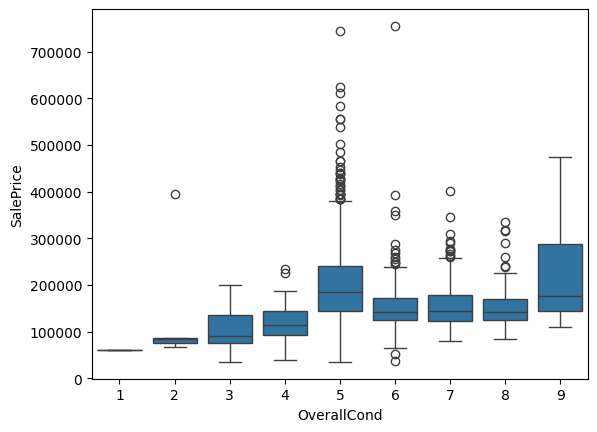

In [53]:
sns.boxplot(x = 'OverallCond', y = 'SalePrice', data = df)

see 5,6, 7 contains more than 90% of the data and they have same range of price . Therefore we can drop this column


In [54]:
df.drop('OverallCond', axis = 1, inplace = True)

<Axes: xlabel='RoofStyle', ylabel='Count'>

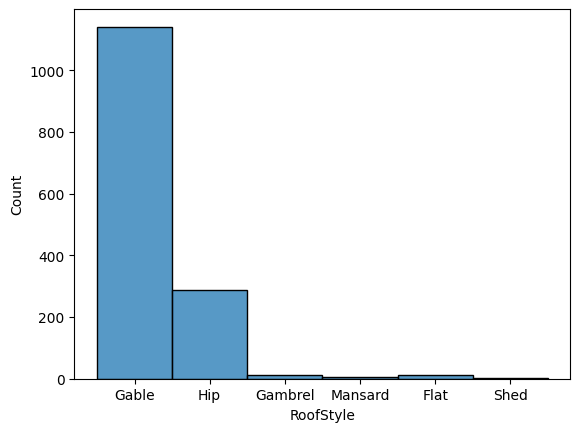

In [55]:
sns.histplot(x = 'RoofStyle', data = df)

<Axes: xlabel='RoofStyle', ylabel='SalePrice'>

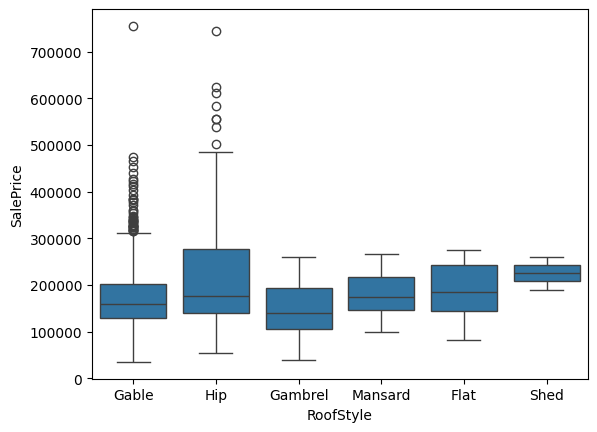

In [56]:
sns.boxplot(x = 'RoofStyle', y = 'SalePrice', data = df)

In [57]:
df.drop('RoofStyle', axis = 1, inplace = True)

In [58]:
df['RoofMatl'].value_counts()

RoofMatl
CompShg    1434
Tar&Grv      11
WdShngl       6
WdShake       5
Metal         1
Membran       1
Roll          1
ClyTile       1
Name: count, dtype: int64

In [59]:
df.drop('RoofMatl', axis = 1, inplace = True)

In [60]:
df['Exterior1st'].value_counts()

Exterior1st
VinylSd    515
HdBoard    222
MetalSd    220
Wd Sdng    206
Plywood    108
CemntBd     61
BrkFace     50
WdShing     26
Stucco      25
AsbShng     20
BrkComm      2
Stone        2
AsphShn      1
ImStucc      1
CBlock       1
Name: count, dtype: int64

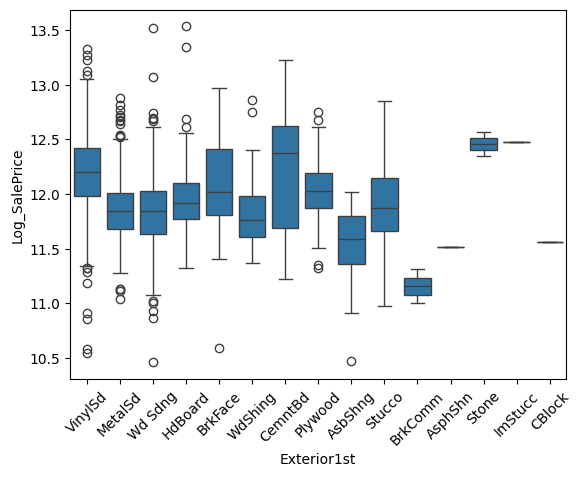

In [61]:
plt.Figure(figsize = (14, 6))
sns.boxplot(x = 'Exterior1st', y = 'Log_SalePrice', data = df)
plt.xticks(rotation = 45)
plt.show()

We can see some relation as the data is evenly distributed and in boxplot, the staircase effect is not shown but if we carefully create the boxplot in descending order , we will get the staircase.

In [62]:
exterior_effect = df.groupby(['Exterior1st'])['SalePrice'].mean()
exterior_effect.sort_values(ascending = False)

Exterior1st
ImStucc    262000.000000
Stone      258500.000000
CemntBd    231690.655738
VinylSd    213732.900971
BrkFace    194573.000000
Plywood    175942.379630
HdBoard    163077.450450
Stucco     162990.000000
WdShing    150655.076923
Wd Sdng    149841.645631
MetalSd    149422.177273
AsbShng    107385.550000
CBlock     105000.000000
AsphShn    100000.000000
BrkComm     71000.000000
Name: SalePrice, dtype: float64

In [63]:
df['Exterior2nd'].value_counts()

Exterior2nd
VinylSd    504
MetalSd    214
HdBoard    207
Wd Sdng    197
Plywood    142
CmentBd     60
Wd Shng     38
Stucco      26
BrkFace     25
AsbShng     20
ImStucc     10
Brk Cmn      7
Stone        5
AsphShn      3
Other        1
CBlock       1
Name: count, dtype: int64

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'VinylSd'),
  Text(1, 0, 'MetalSd'),
  Text(2, 0, 'Wd Shng'),
  Text(3, 0, 'HdBoard'),
  Text(4, 0, 'Plywood'),
  Text(5, 0, 'Wd Sdng'),
  Text(6, 0, 'CmentBd'),
  Text(7, 0, 'BrkFace'),
  Text(8, 0, 'Stucco'),
  Text(9, 0, 'AsbShng'),
  Text(10, 0, 'Brk Cmn'),
  Text(11, 0, 'ImStucc'),
  Text(12, 0, 'AsphShn'),
  Text(13, 0, 'Stone'),
  Text(14, 0, 'Other'),
  Text(15, 0, 'CBlock')])

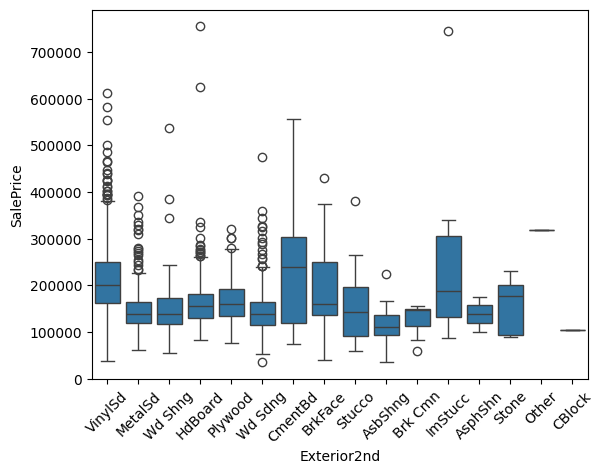

In [64]:
sns.boxplot(x = 'Exterior2nd', y = 'SalePrice', data = df)
plt.xticks(rotation = 45)

In [65]:
exterior2 = df.groupby(['Exterior2nd'])['SalePrice'].mean().sort_values(ascending = False)
exterior2

Exterior2nd
Other      319000.000000
ImStucc    252070.000000
CmentBd    230093.833333
VinylSd    214432.460317
BrkFace    195818.000000
Plywood    168112.387324
HdBoard    167661.565217
Wd Shng    161328.947368
Stone      158224.800000
Stucco     155905.153846
MetalSd    149803.172897
Wd Sdng    148386.065990
AsphShn    138000.000000
Brk Cmn    126714.285714
AsbShng    114060.550000
CBlock     105000.000000
Name: SalePrice, dtype: float64

In [66]:
df['MasVnrType'].value_counts()

MasVnrType
None       872
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

<Axes: xlabel='MasVnrType', ylabel='SalePrice'>

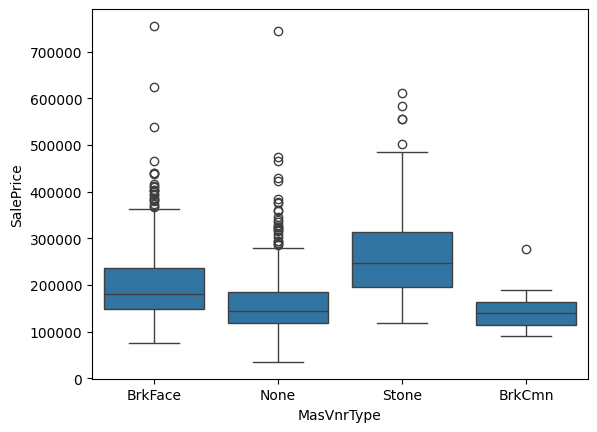

In [67]:
sns.boxplot(x = 'MasVnrType', y = 'SalePrice', data = df)

In [68]:
df['ExterQual'].value_counts()

ExterQual
TA    906
Gd    488
Ex     52
Fa     14
Name: count, dtype: int64

<Axes: xlabel='ExterQual', ylabel='SalePrice'>

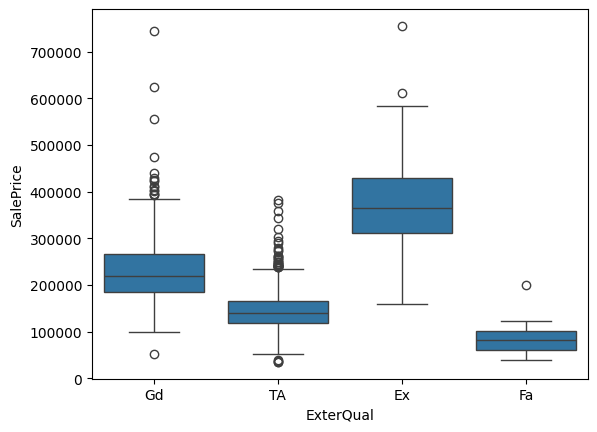

In [69]:
sns.boxplot(x = df['ExterQual'], y = df['SalePrice'])

In [70]:
df['ExterCond'].value_counts()

ExterCond
TA    1282
Gd     146
Fa      28
Ex       3
Po       1
Name: count, dtype: int64

<Axes: xlabel='ExterCond', ylabel='SalePrice'>

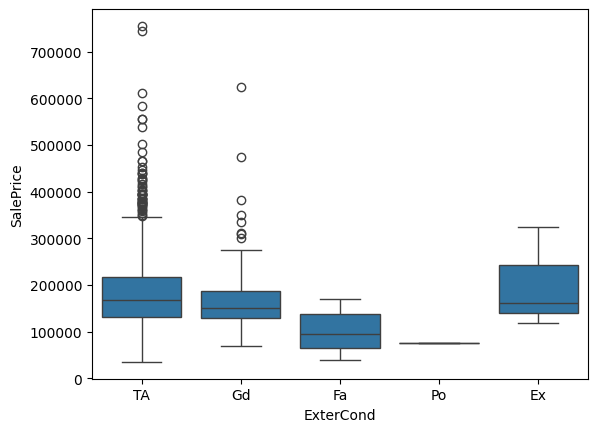

In [71]:
sns.boxplot(x = 'ExterCond', y = 'SalePrice', data = df)

In [72]:
df['Foundation'].value_counts()

Foundation
PConc     647
CBlock    634
BrkTil    146
Slab       24
Stone       6
Wood        3
Name: count, dtype: int64

<Axes: xlabel='Foundation', ylabel='SalePrice'>

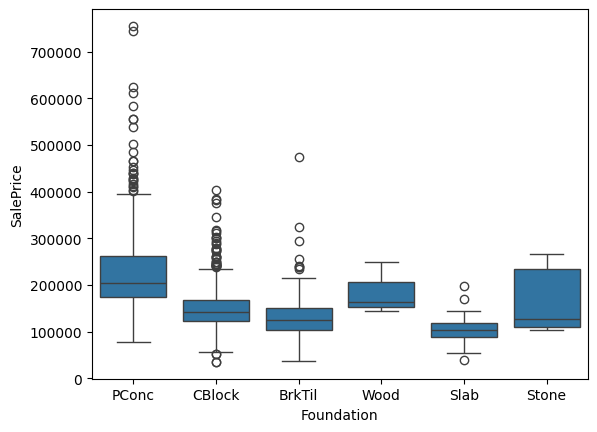

In [73]:
sns.boxplot(x = 'Foundation', y = 'SalePrice', data = df)

In [74]:
df['BsmtQual'].value_counts()

BsmtQual
TA      649
Gd      618
Ex      121
None     37
Fa       35
Name: count, dtype: int64

<Axes: xlabel='BsmtQual', ylabel='SalePrice'>

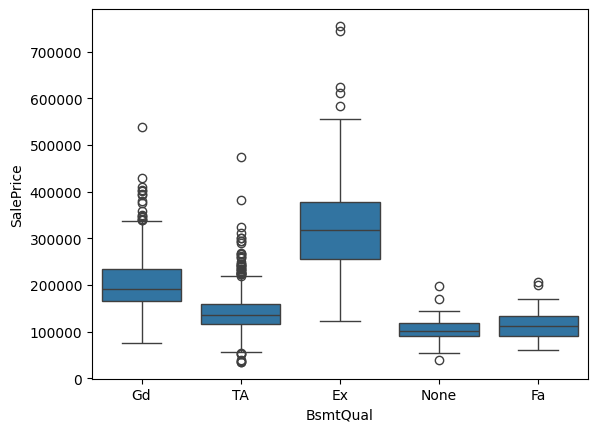

In [75]:
sns.boxplot(x = 'BsmtQual', y = 'SalePrice', data = df)

In [76]:
df['BsmtCond'].value_counts()

BsmtCond
TA      1311
Gd        65
Fa        45
None      37
Po         2
Name: count, dtype: int64

In [77]:
df.drop(['BsmtCond'], axis =1 ,inplace=True)

In [78]:
df['BsmtExposure'].value_counts()

BsmtExposure
No      953
Av      221
Gd      134
Mn      114
None     38
Name: count, dtype: int64

<Axes: xlabel='BsmtExposure', ylabel='SalePrice'>

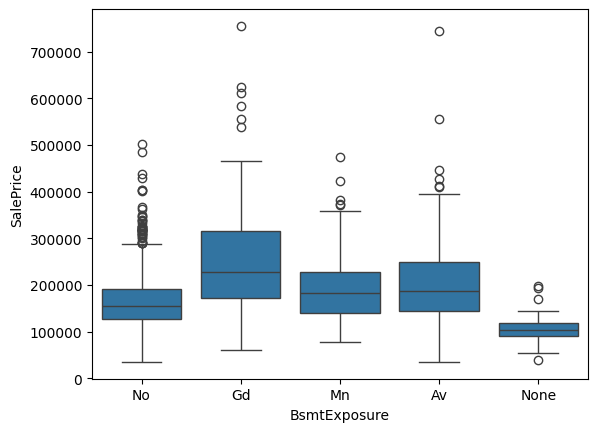

In [79]:
sns.boxplot(x = 'BsmtExposure', y = 'SalePrice', data = df)

In [80]:
df['BsmtFinType1'].value_counts()

BsmtFinType1
Unf     430
GLQ     418
ALQ     220
BLQ     148
Rec     133
LwQ      74
None     37
Name: count, dtype: int64

<Axes: xlabel='BsmtFinType1', ylabel='SalePrice'>

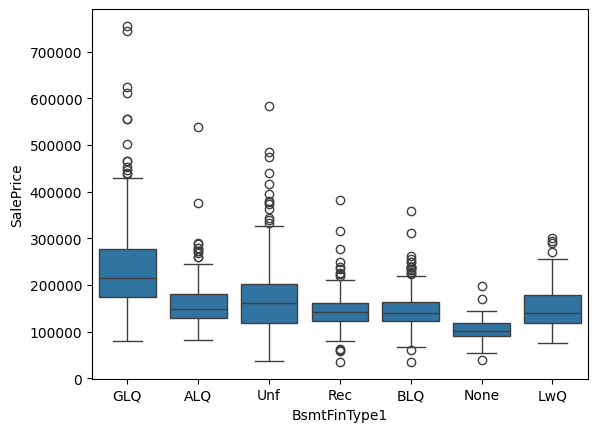

In [81]:
sns.boxplot(x = df['BsmtFinType1'], y = df['SalePrice'])

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


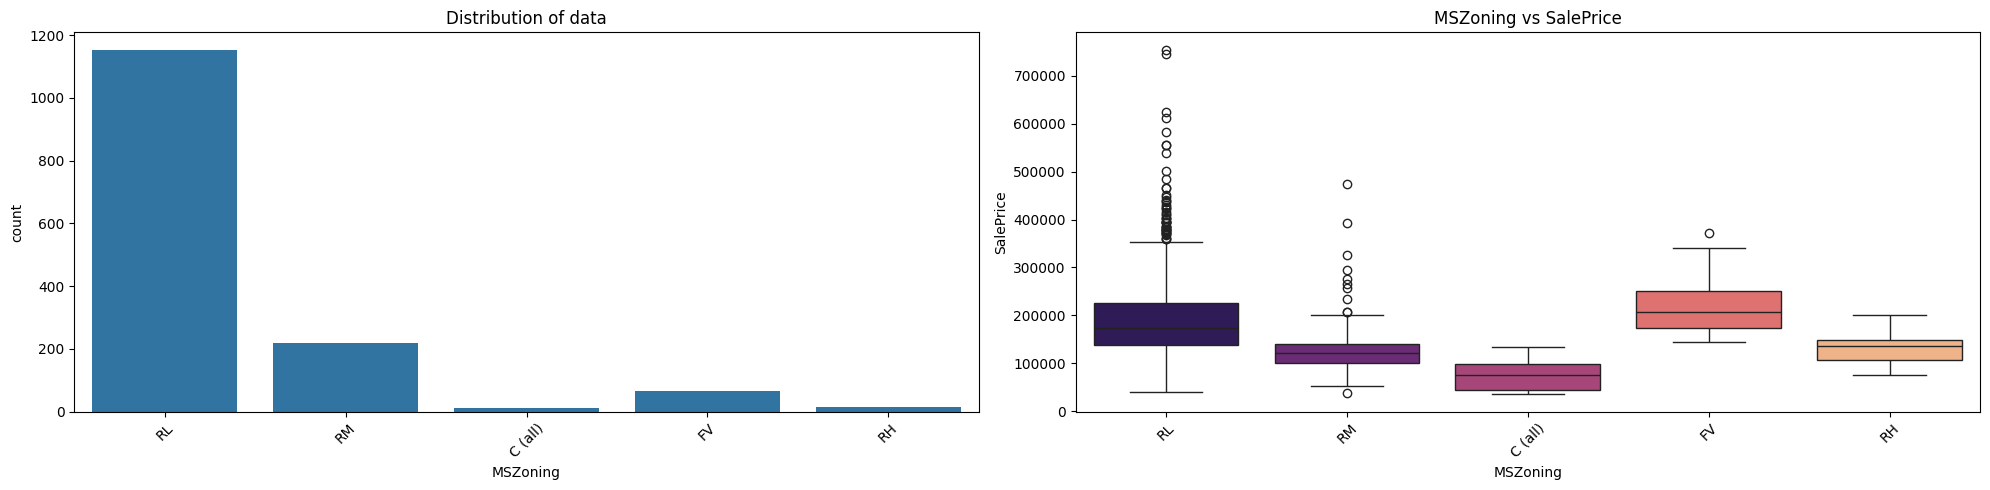

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


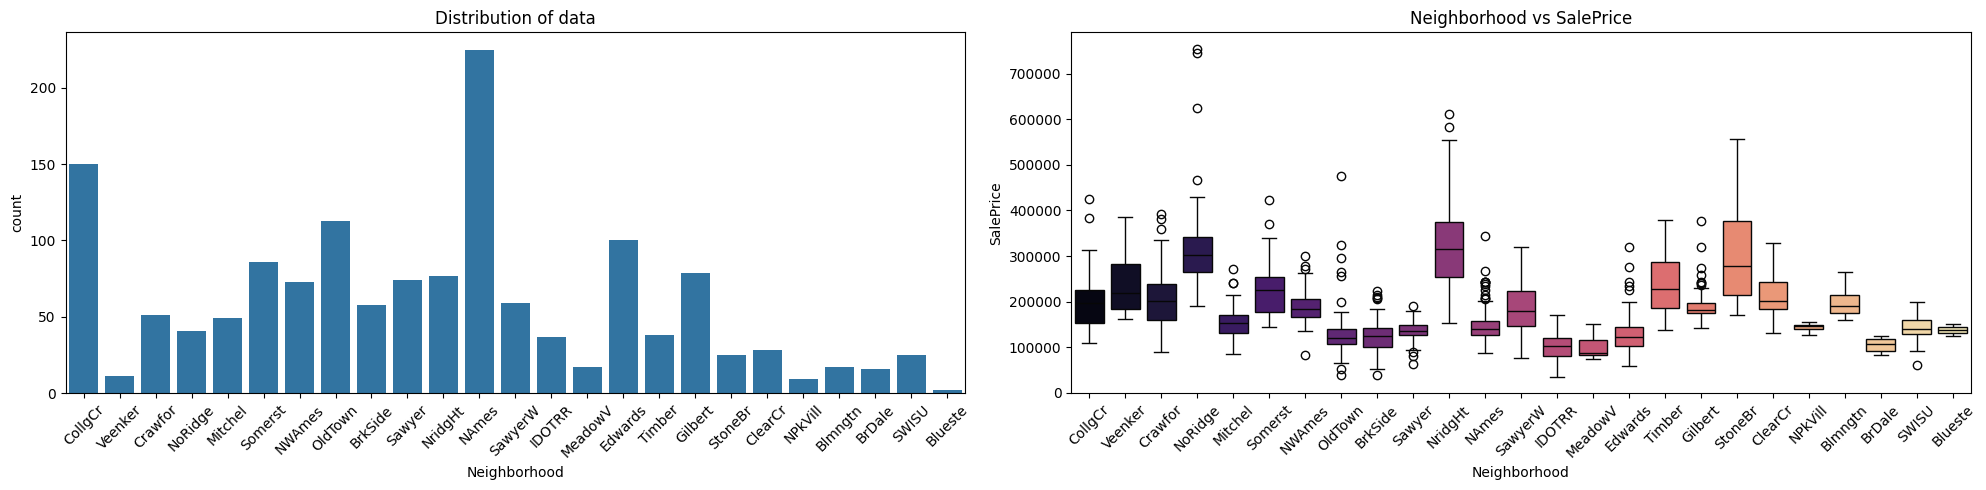

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


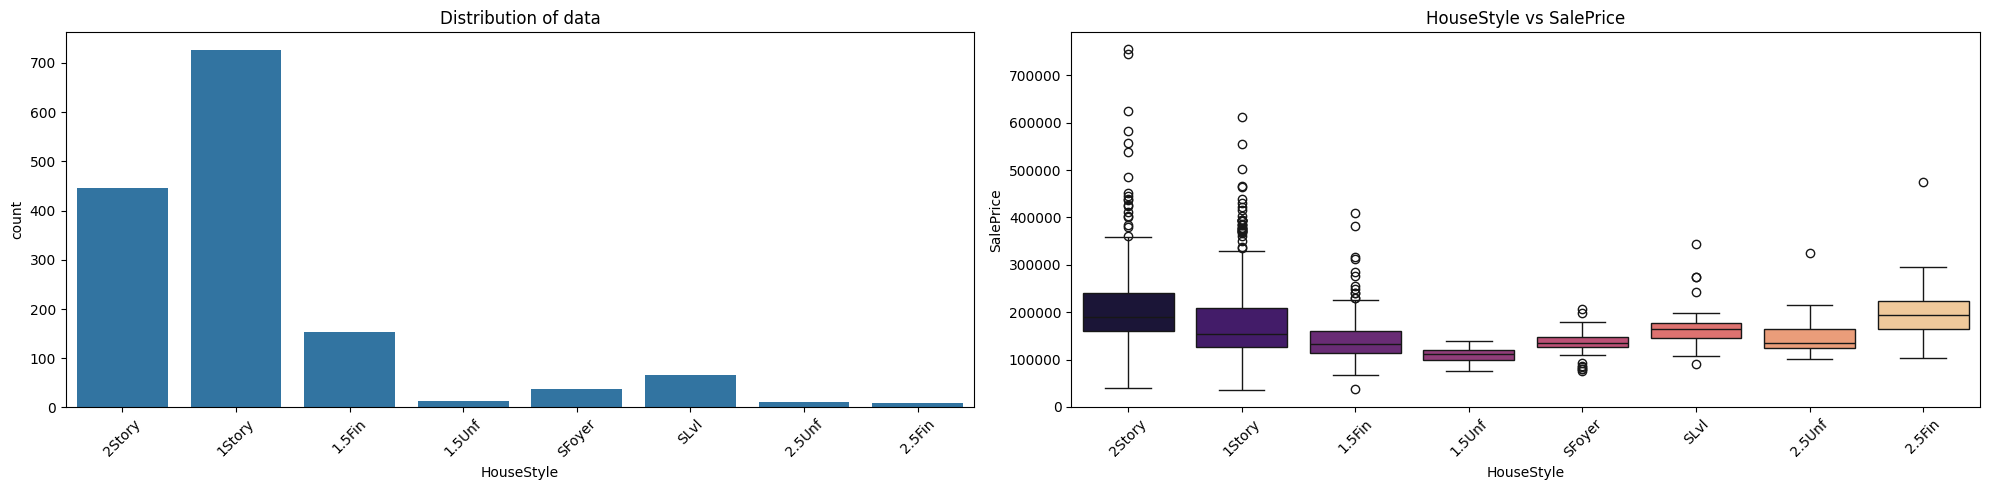

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


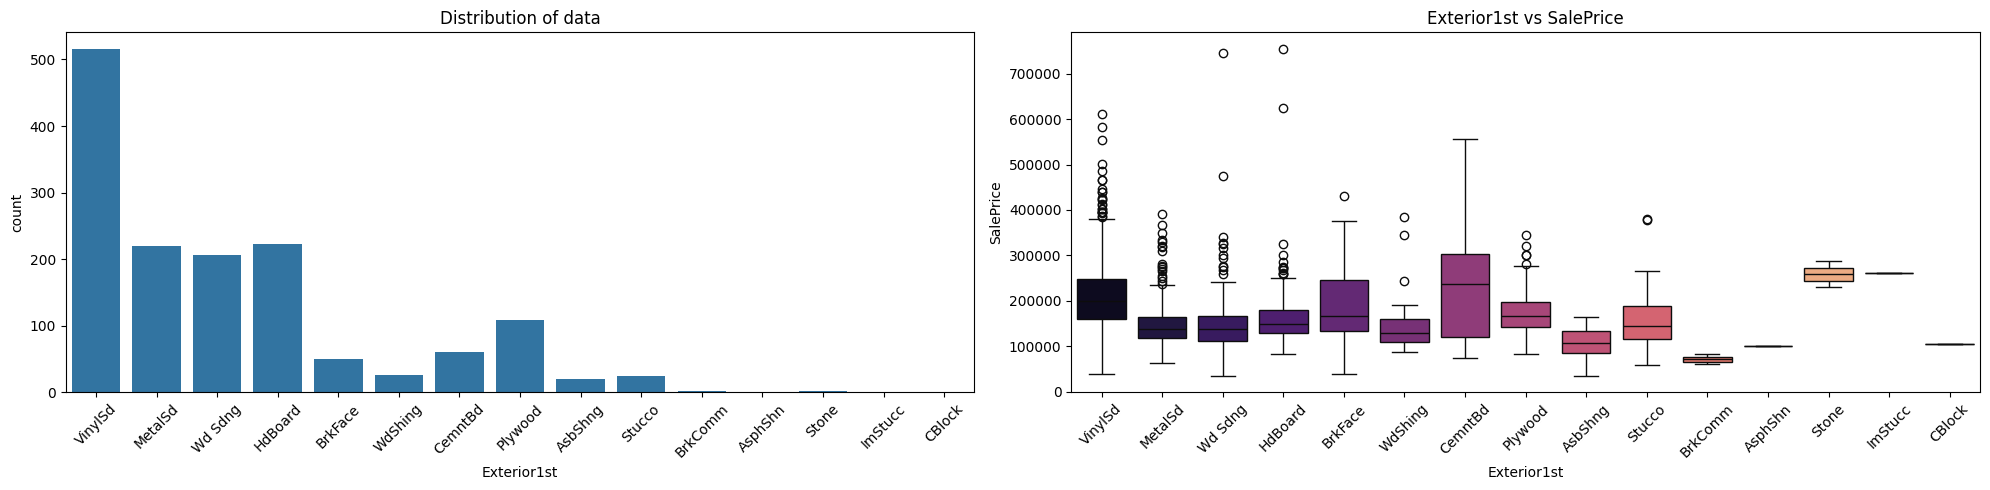

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


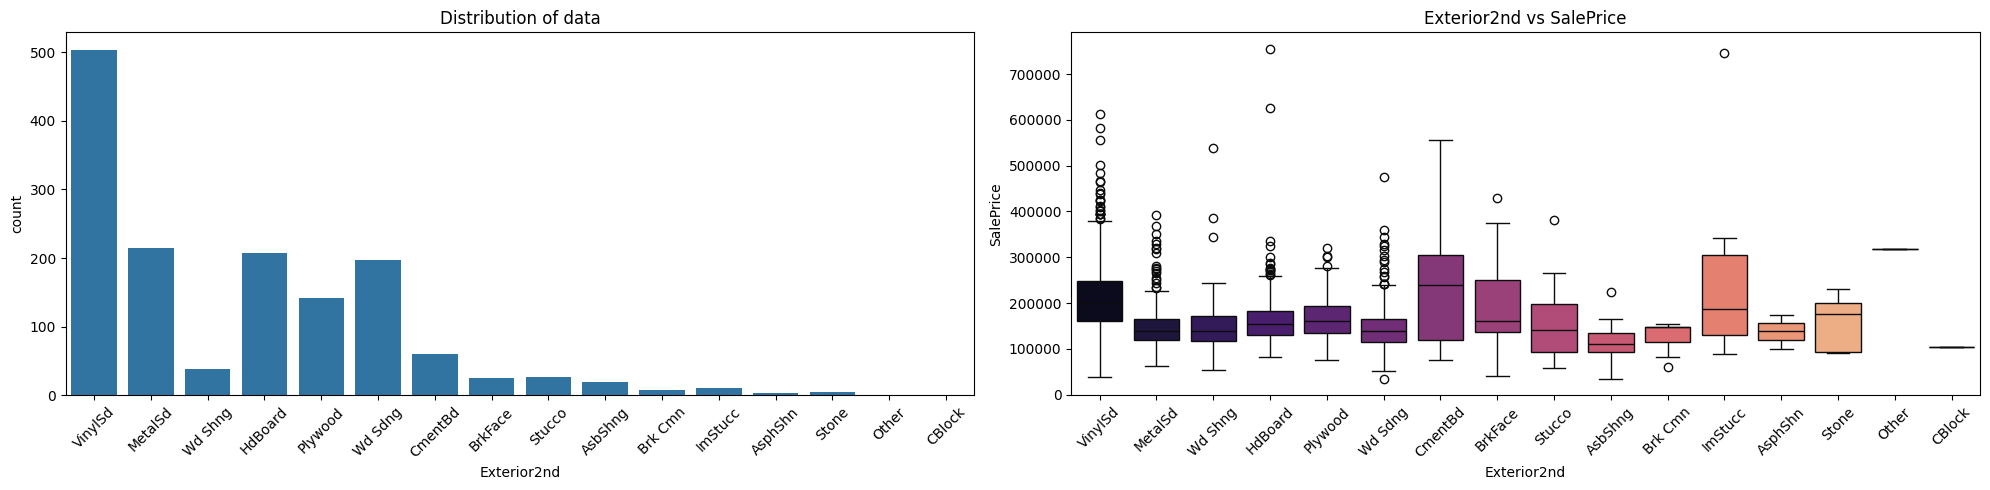

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


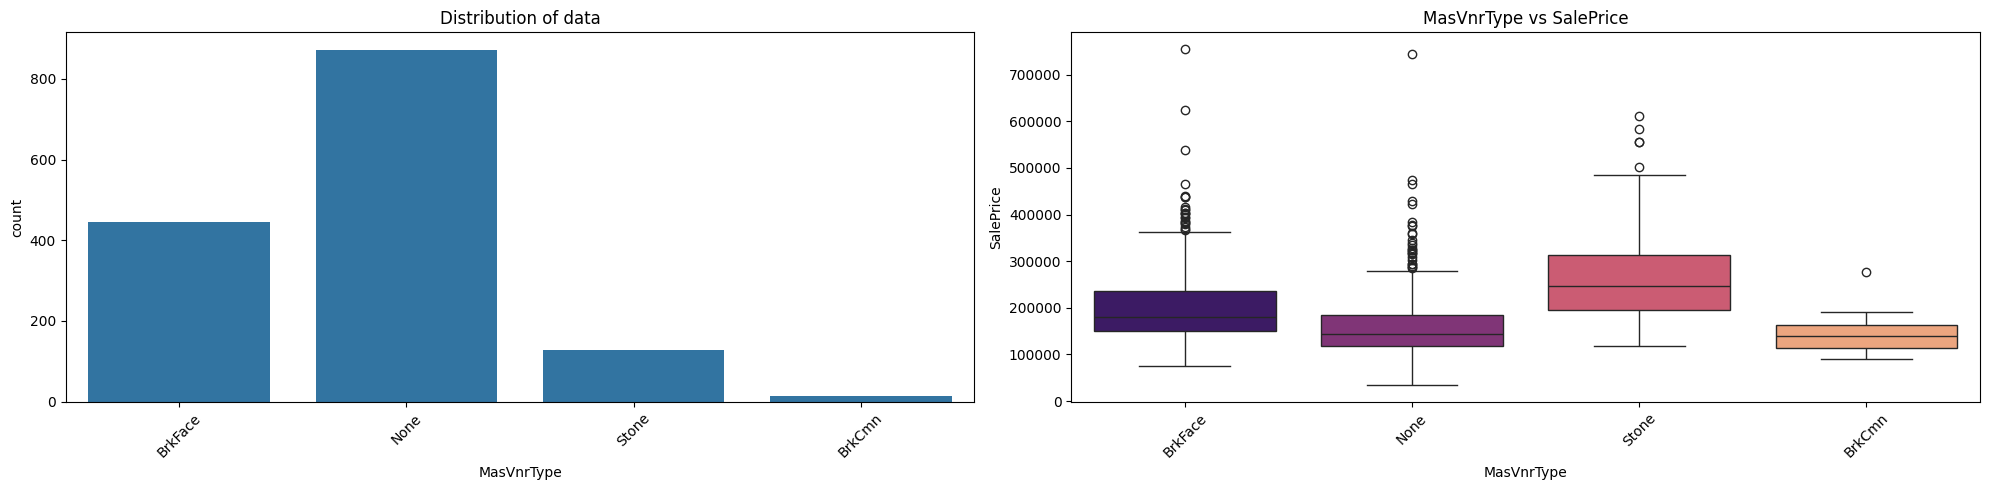

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


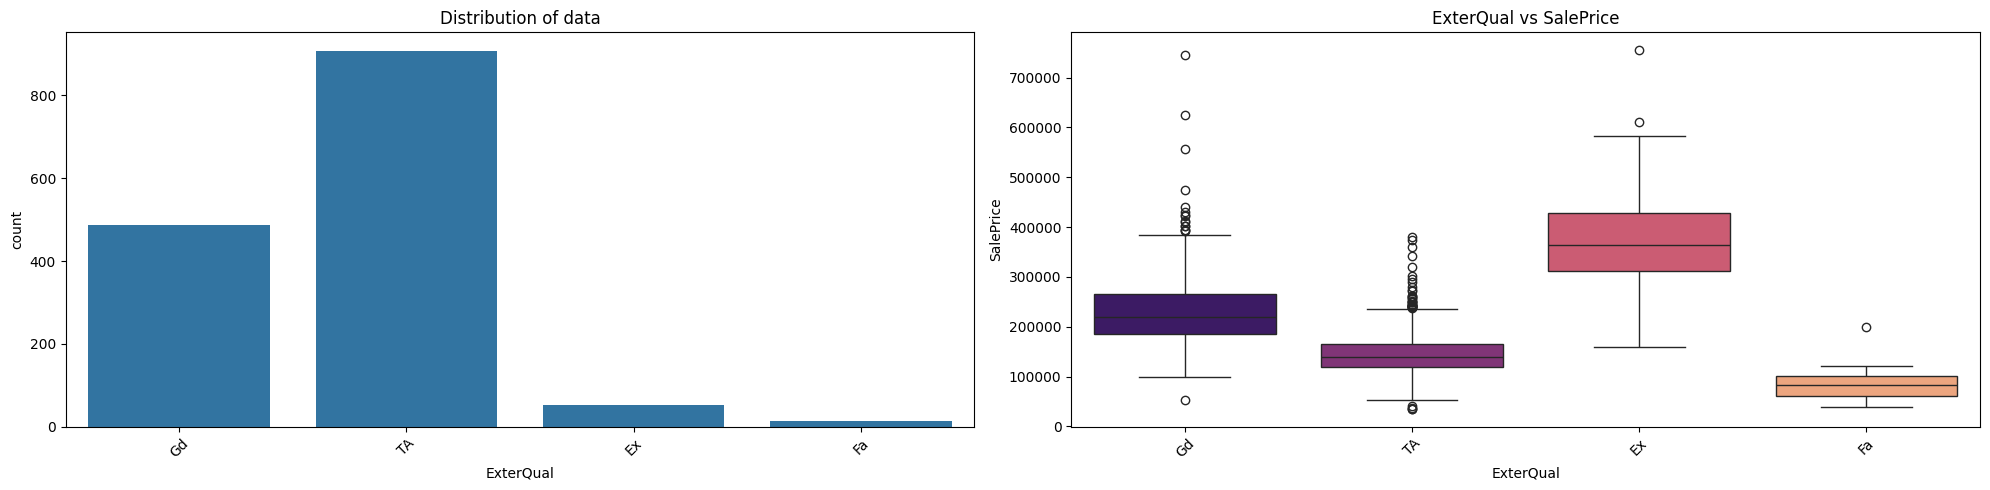

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


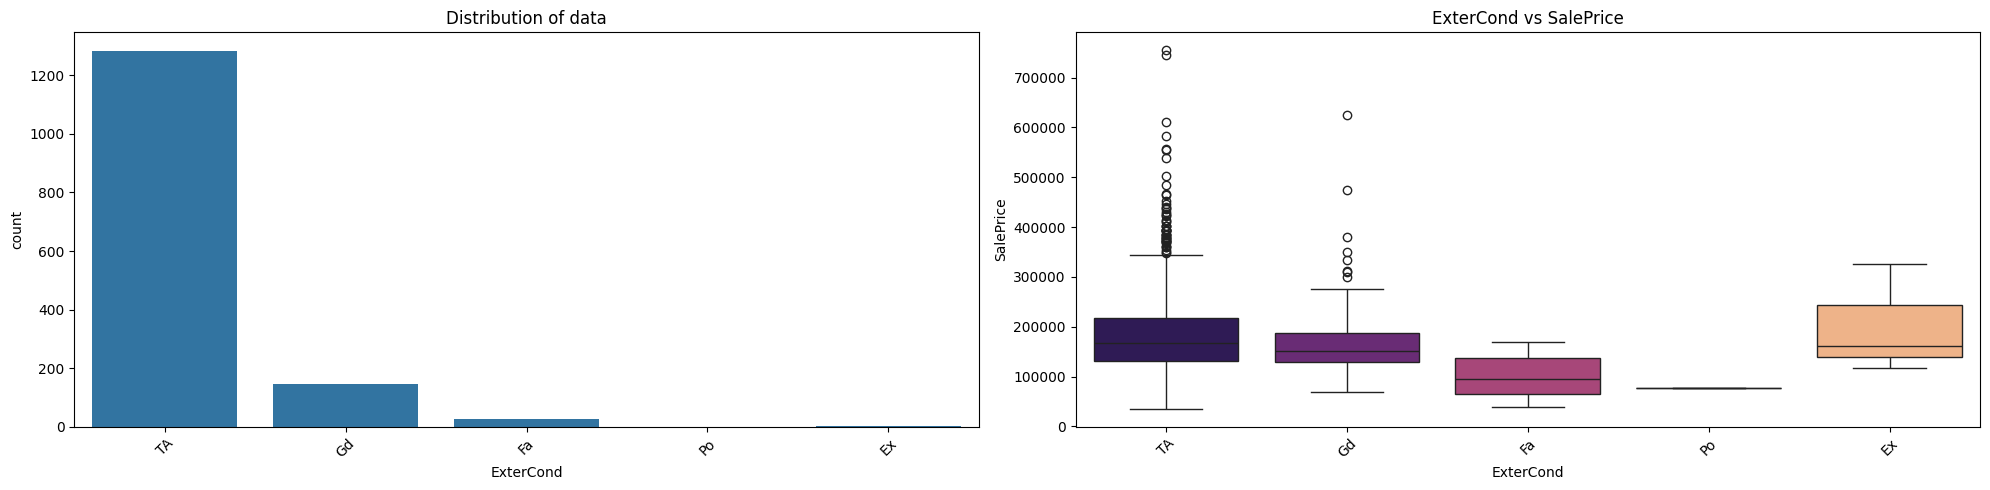

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


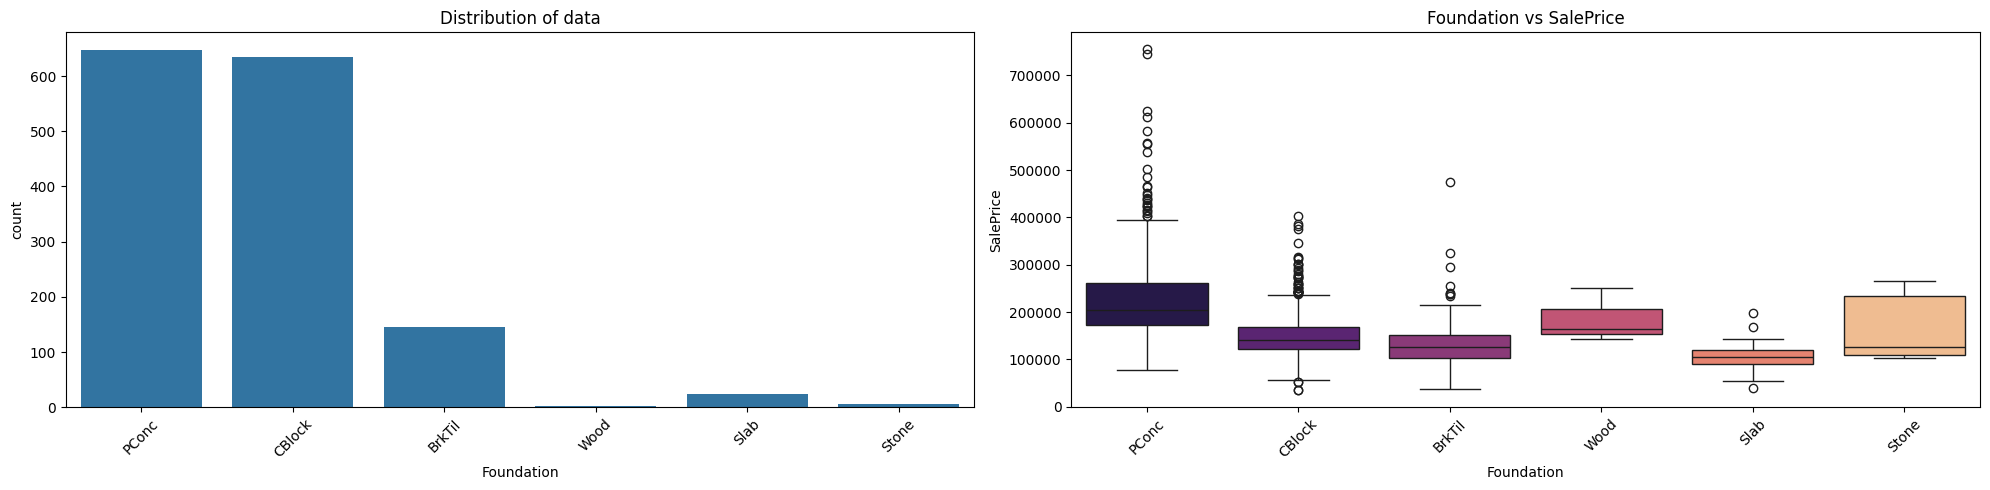

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


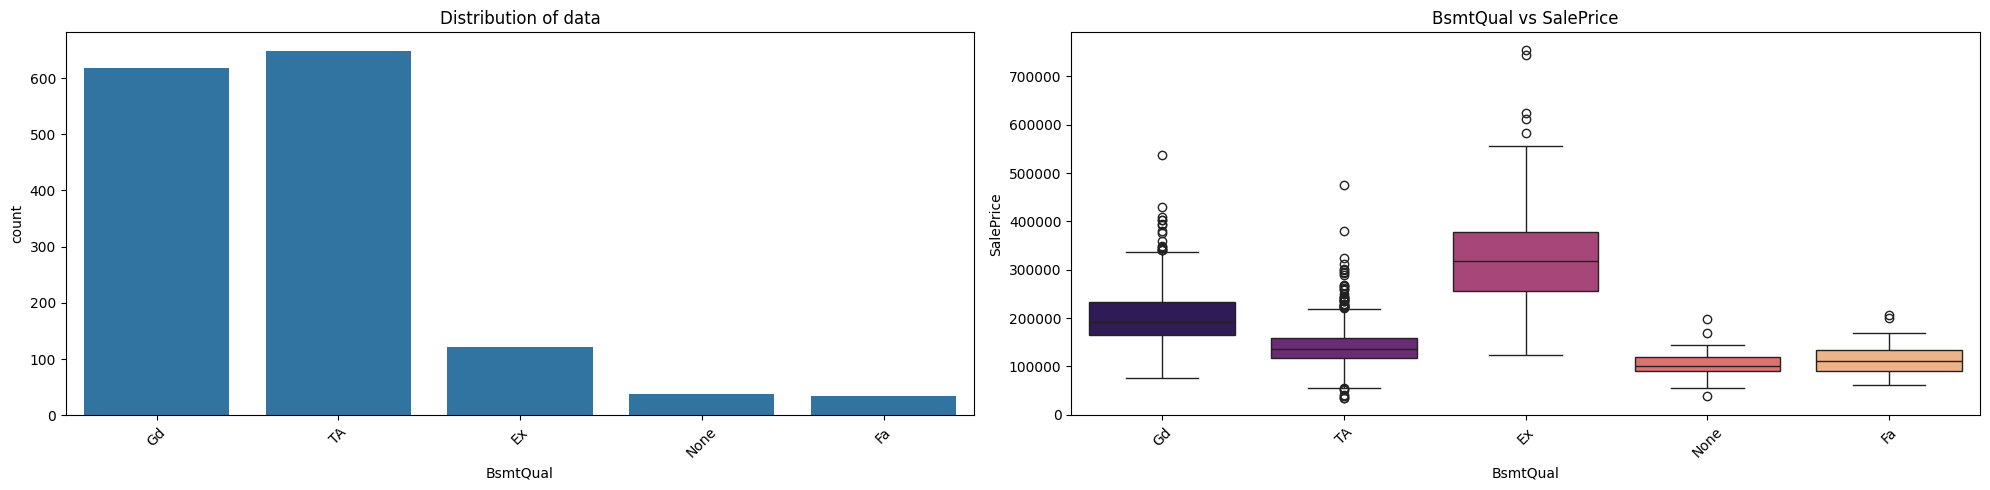

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


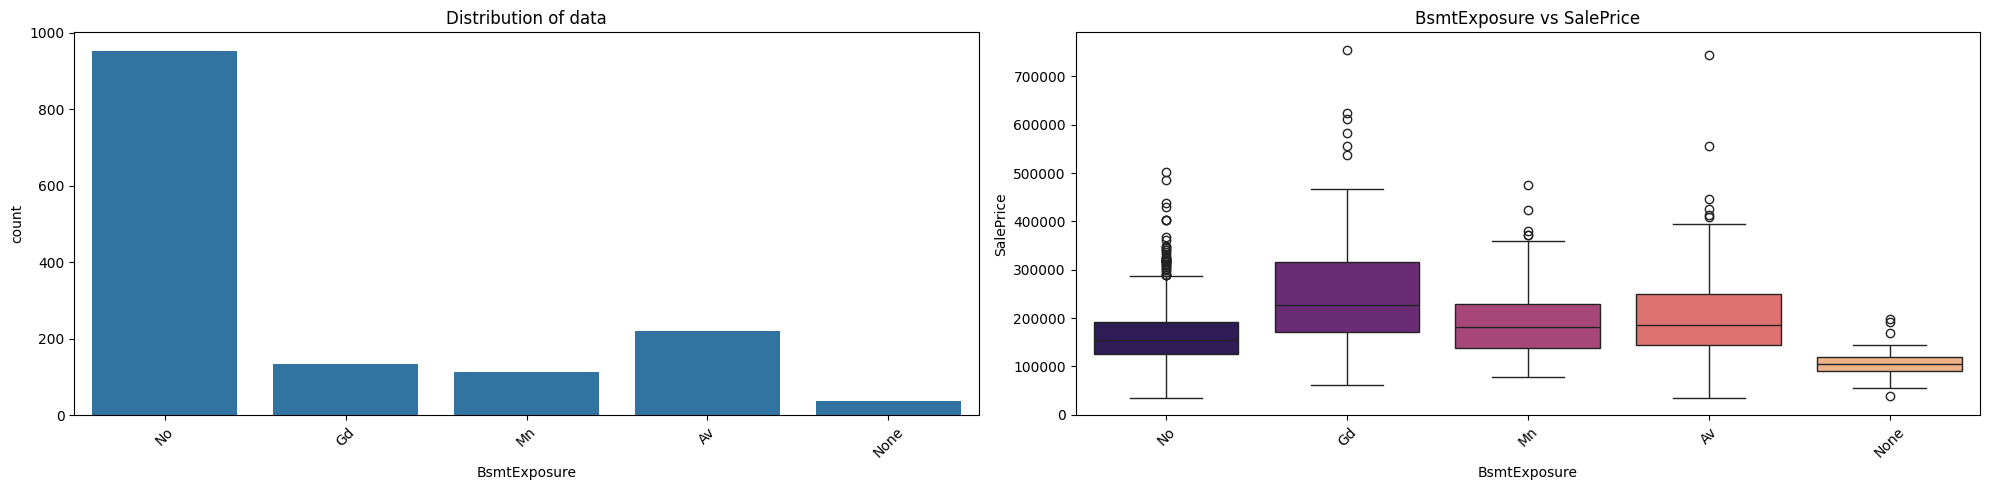

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


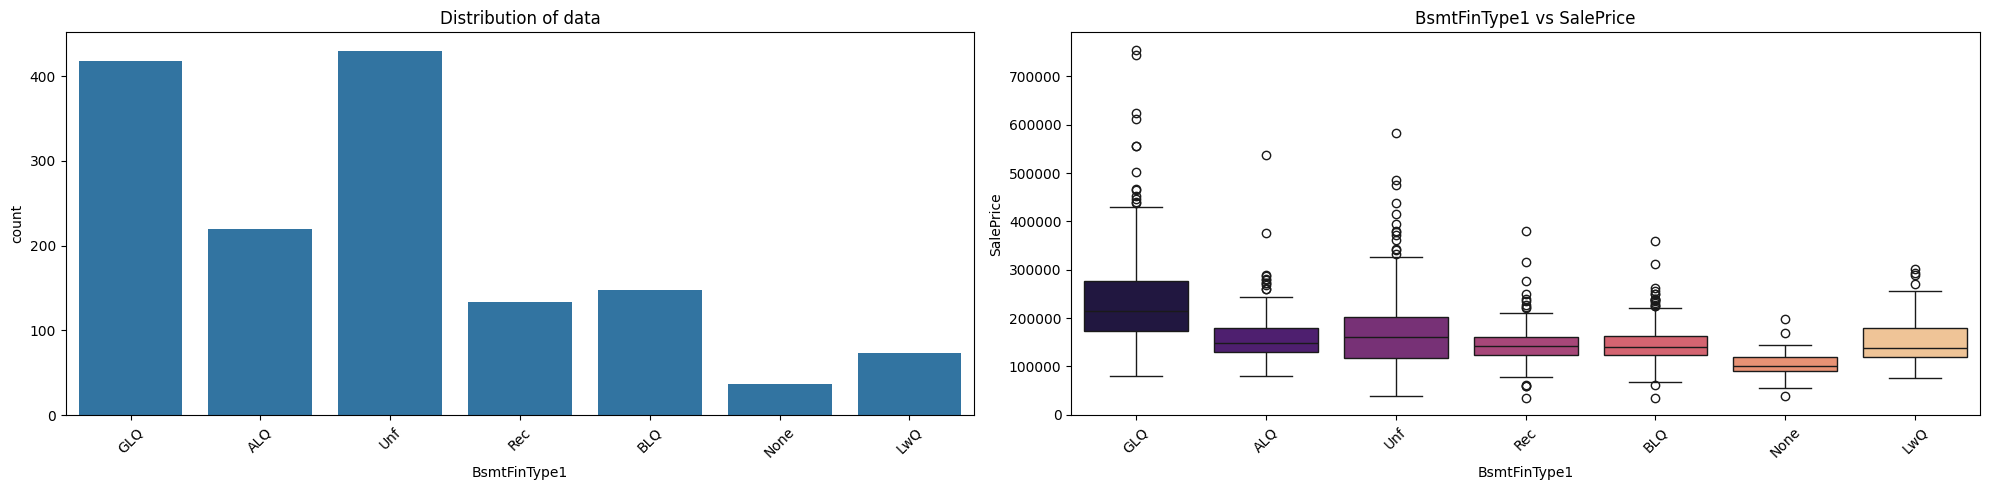

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


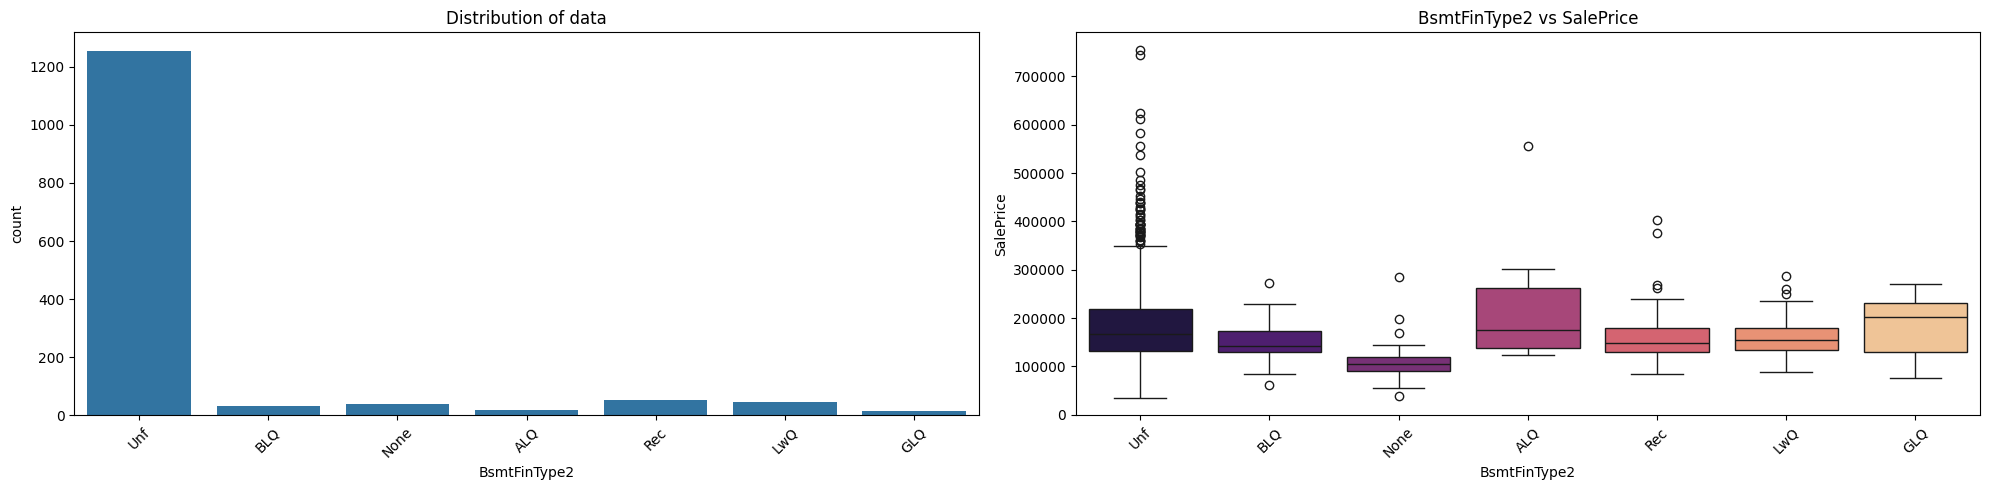

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


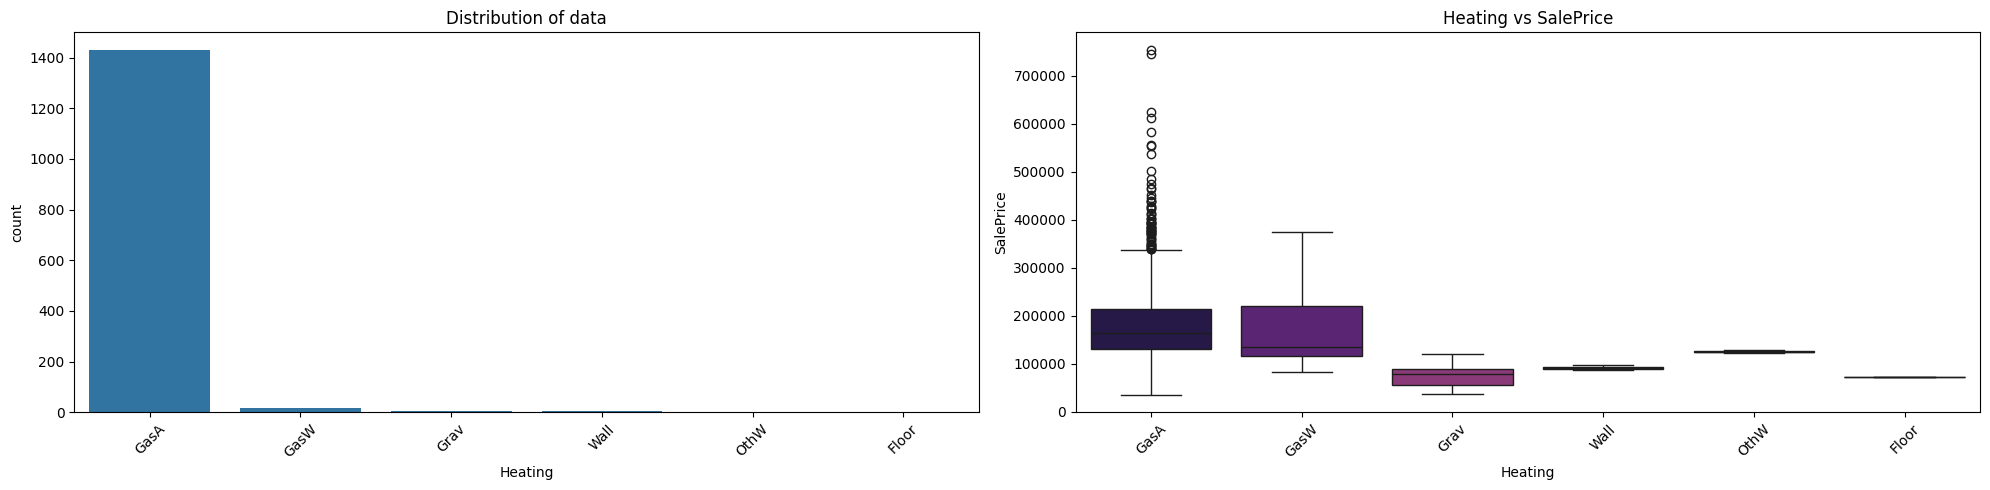

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


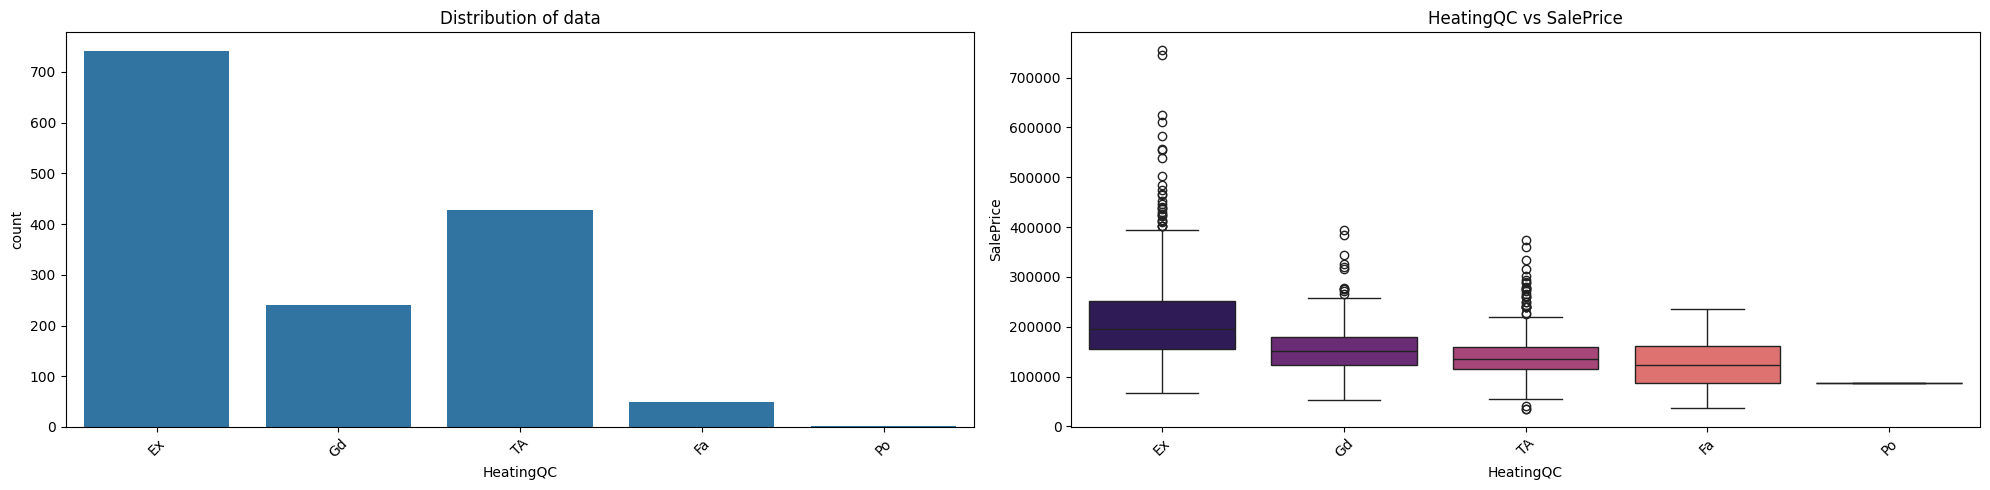

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


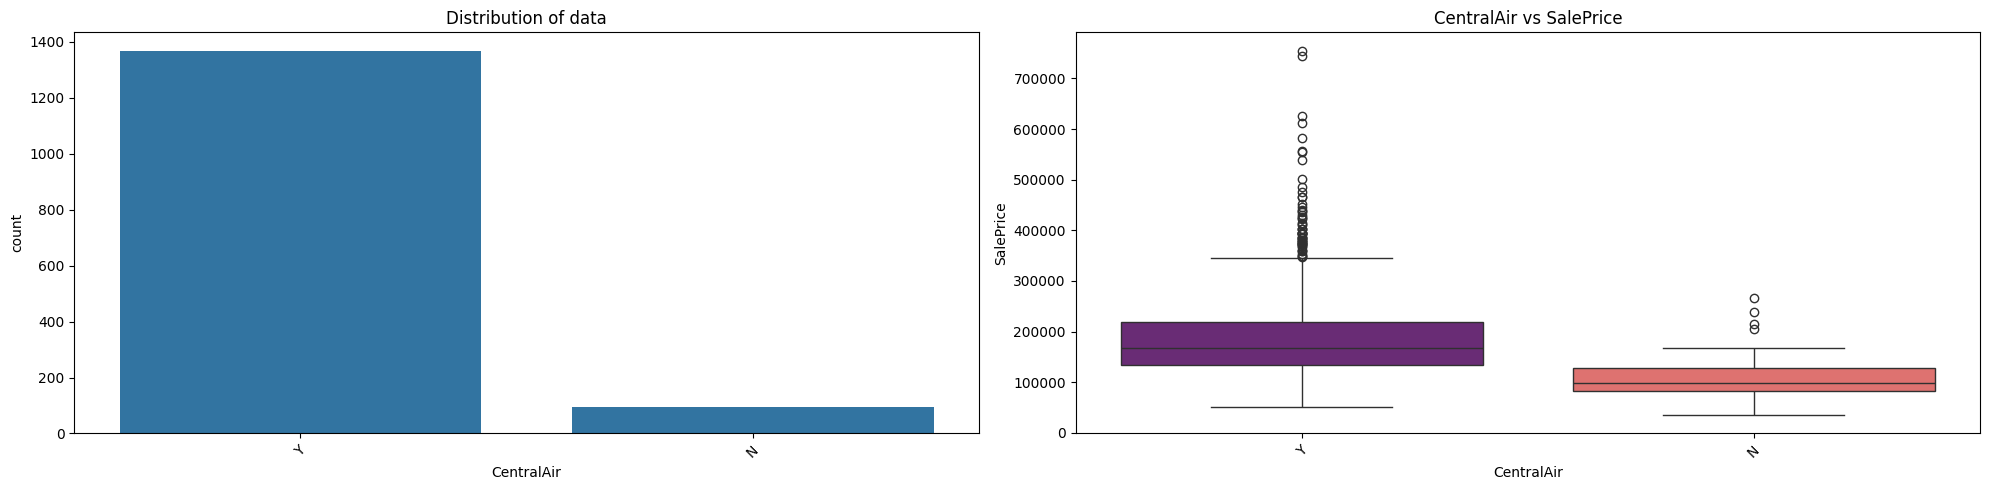

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


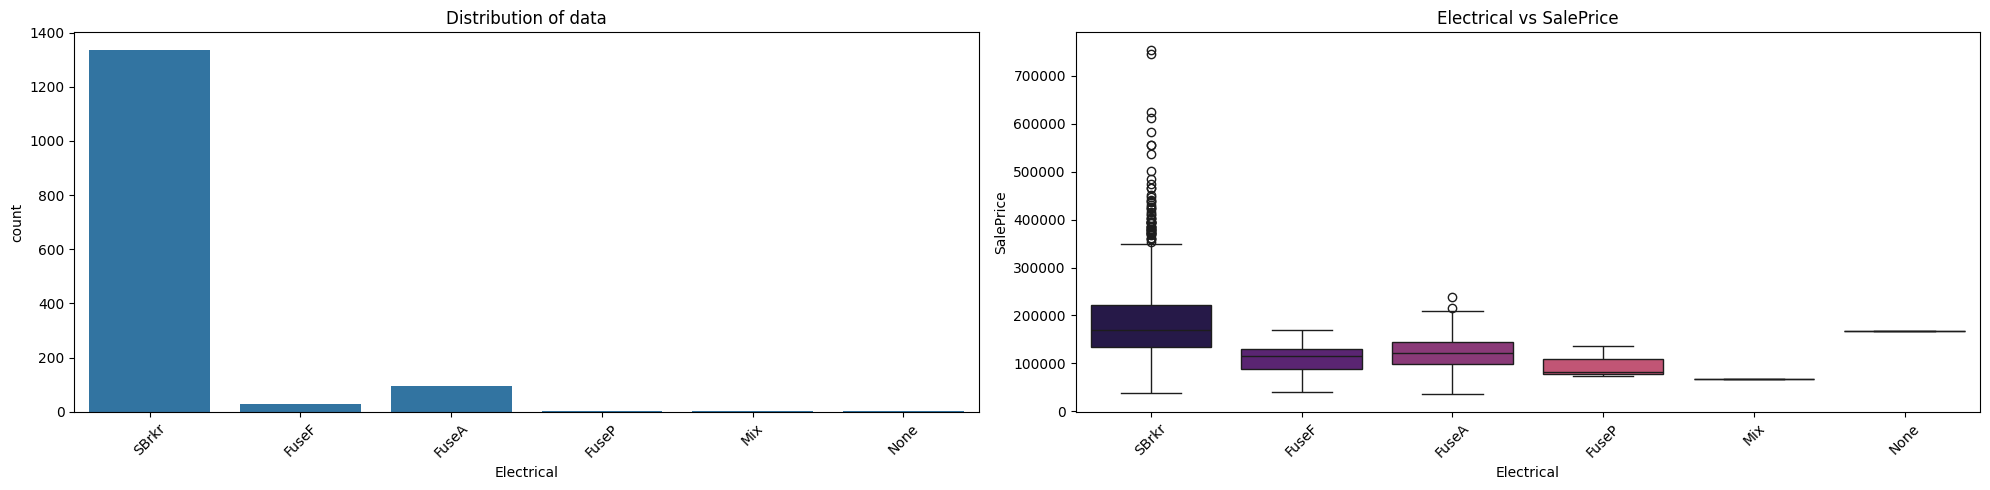

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


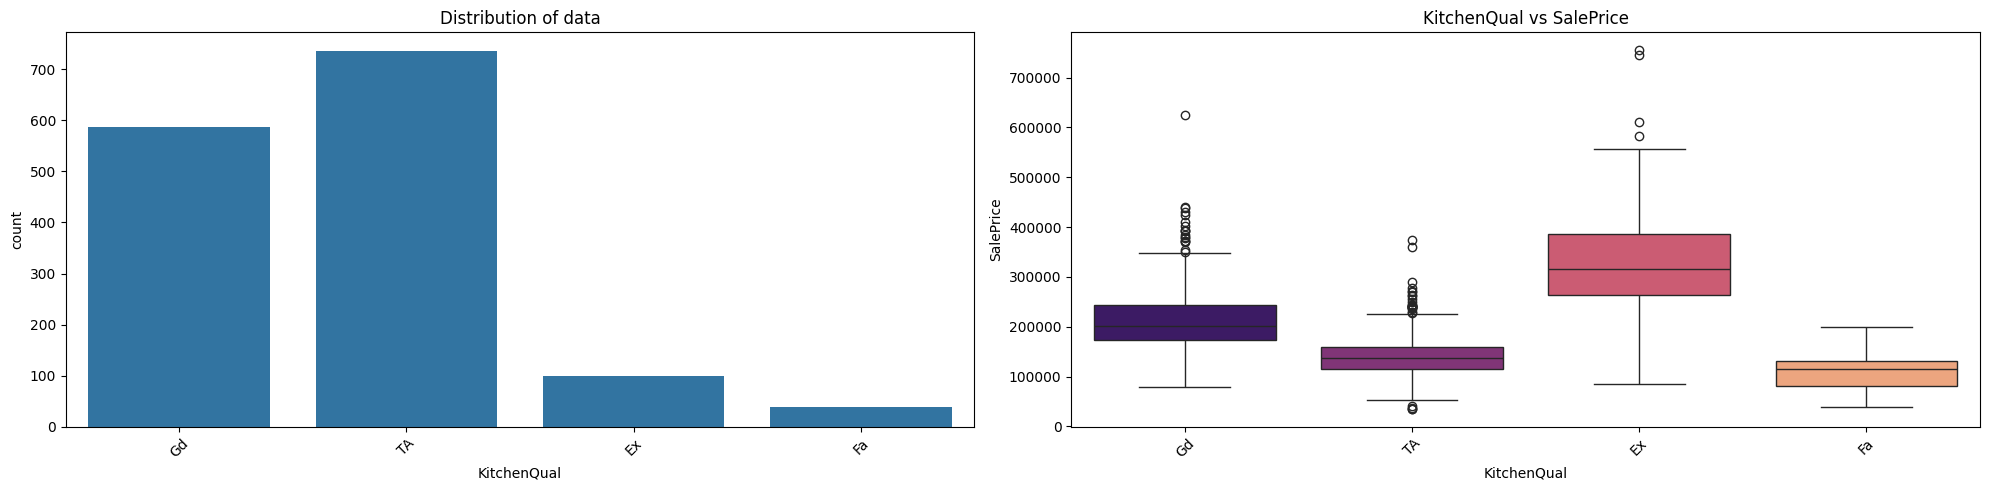

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


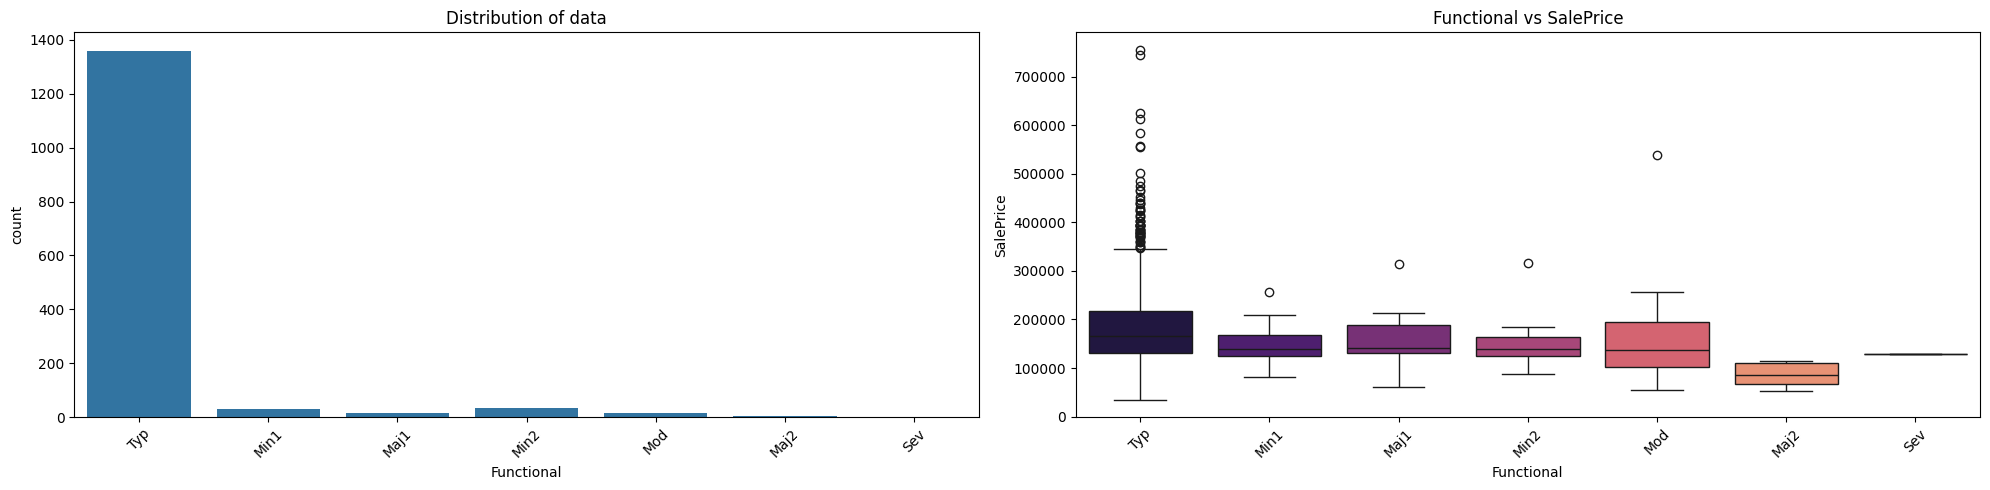

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


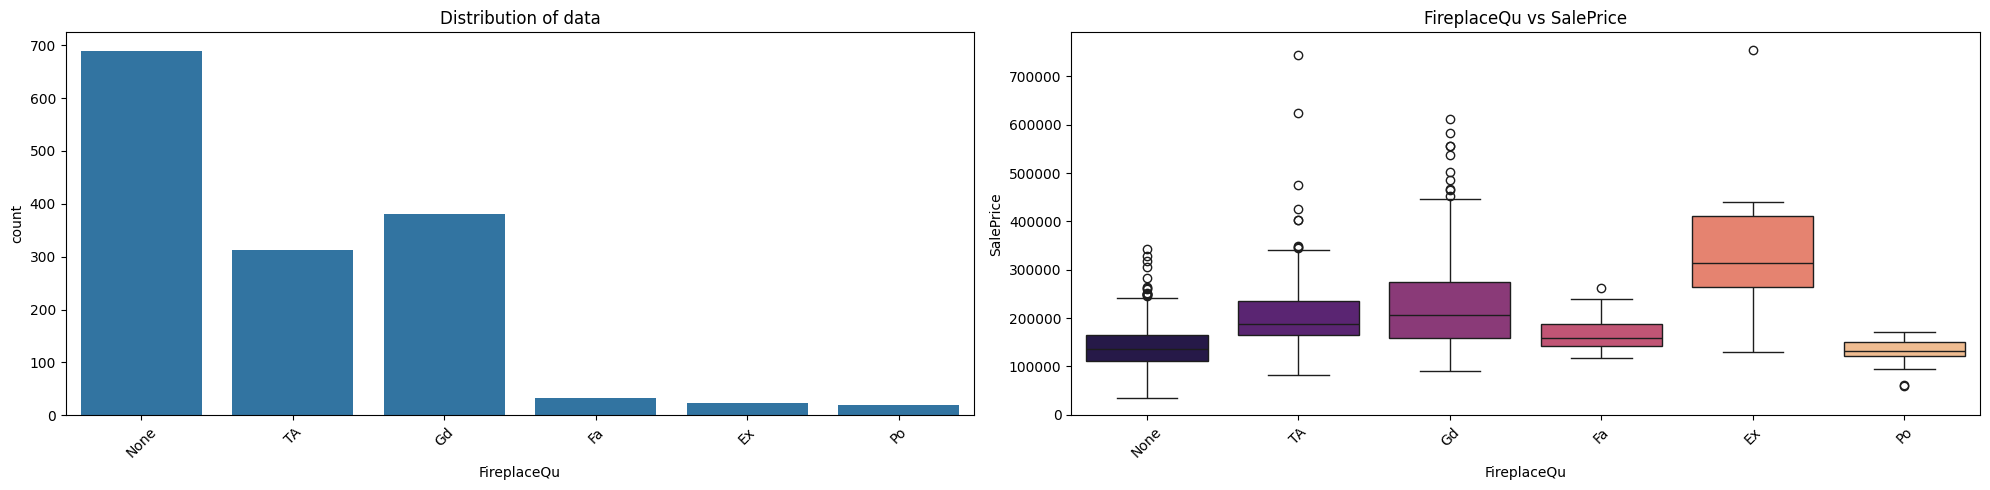

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


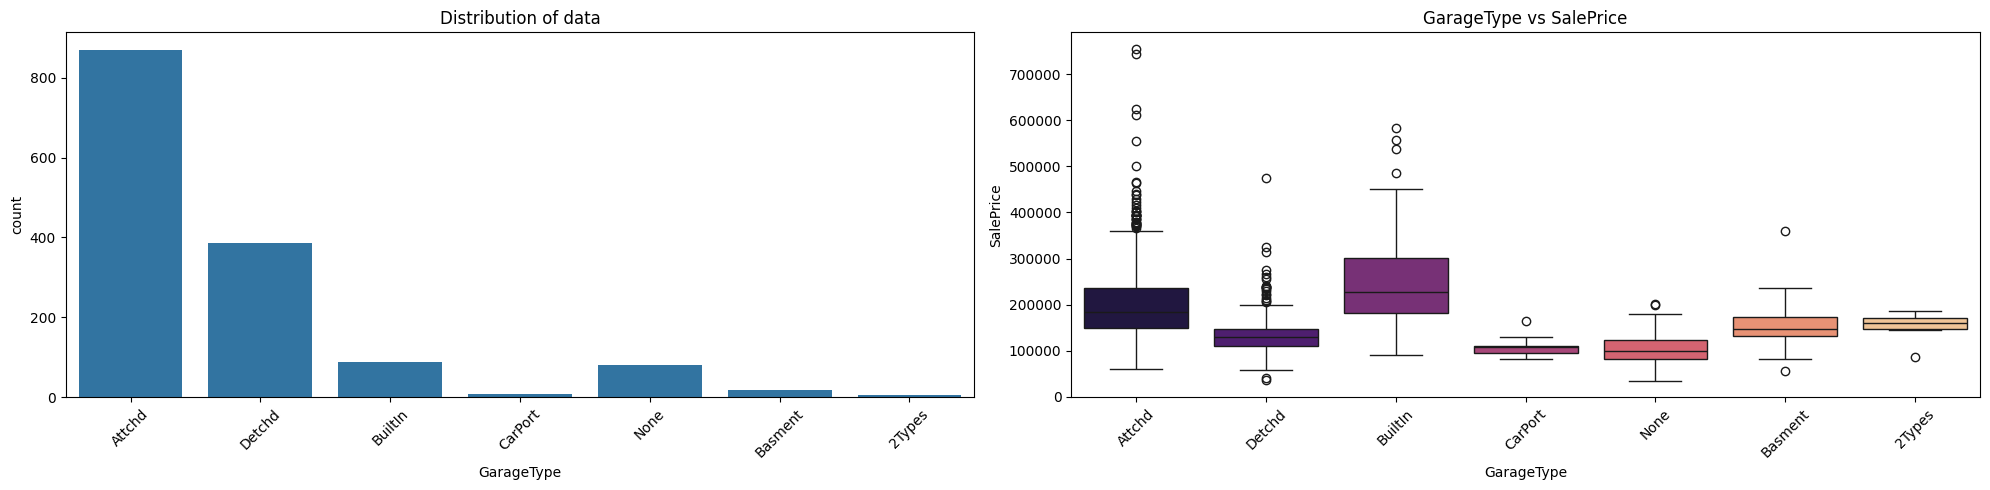

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


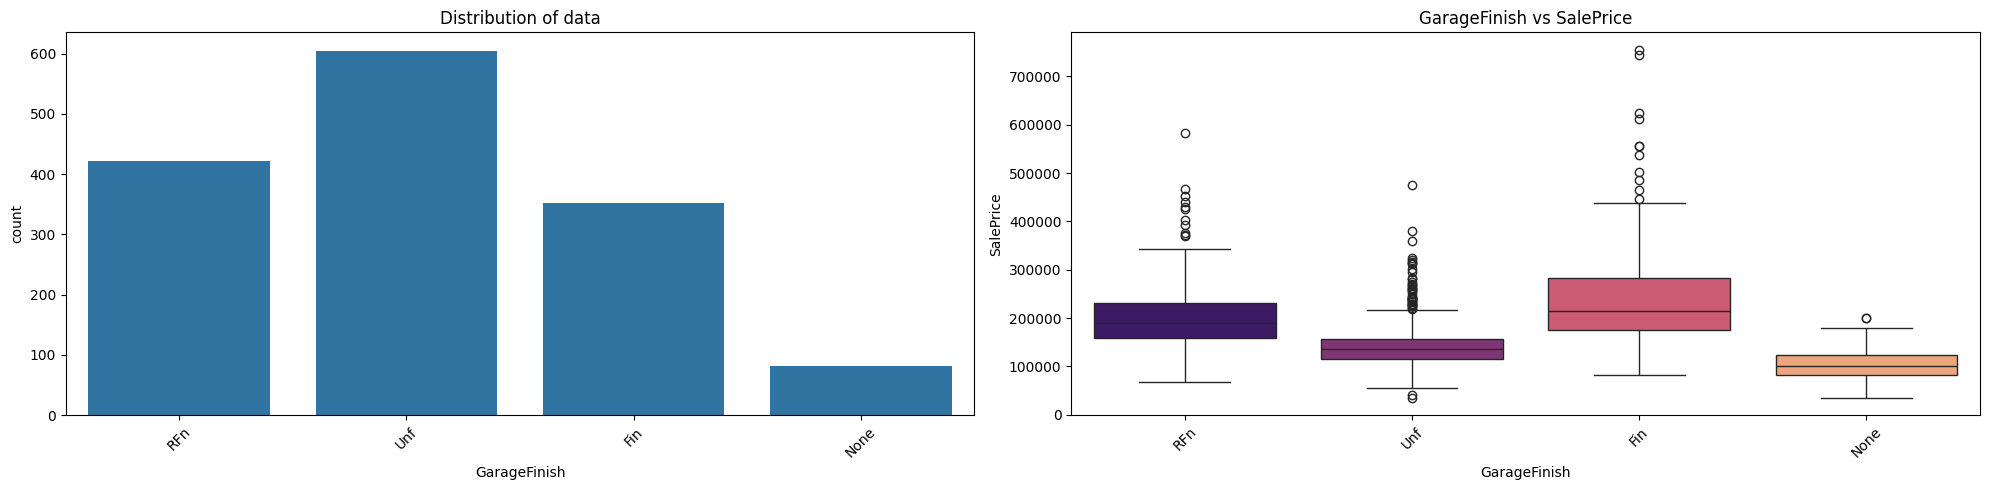

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


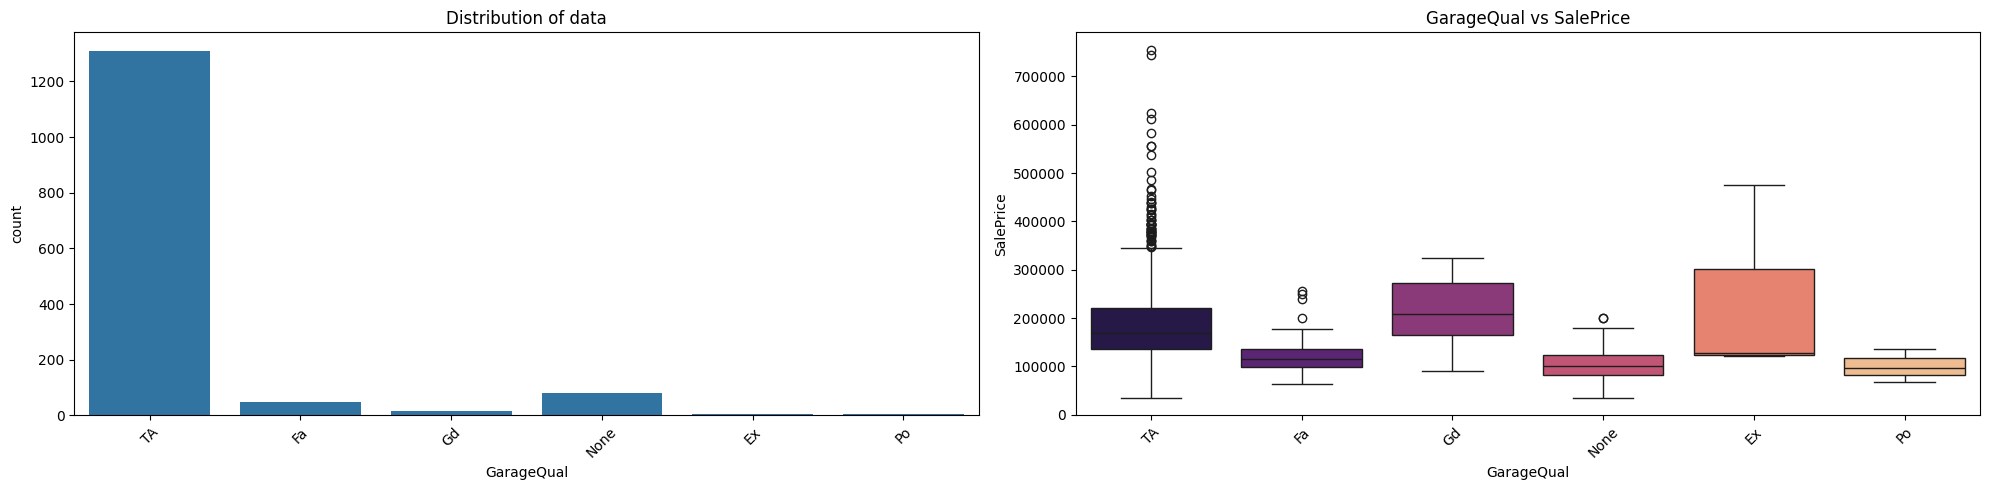

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


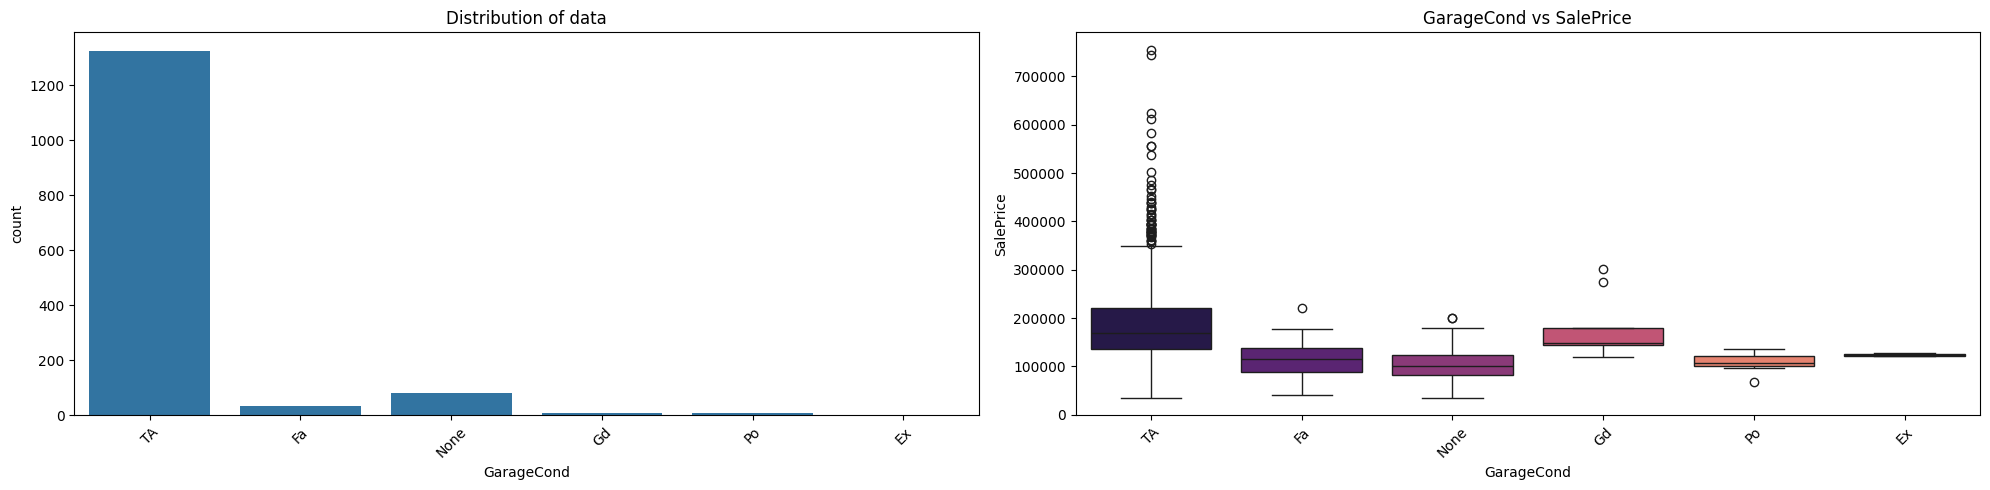

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


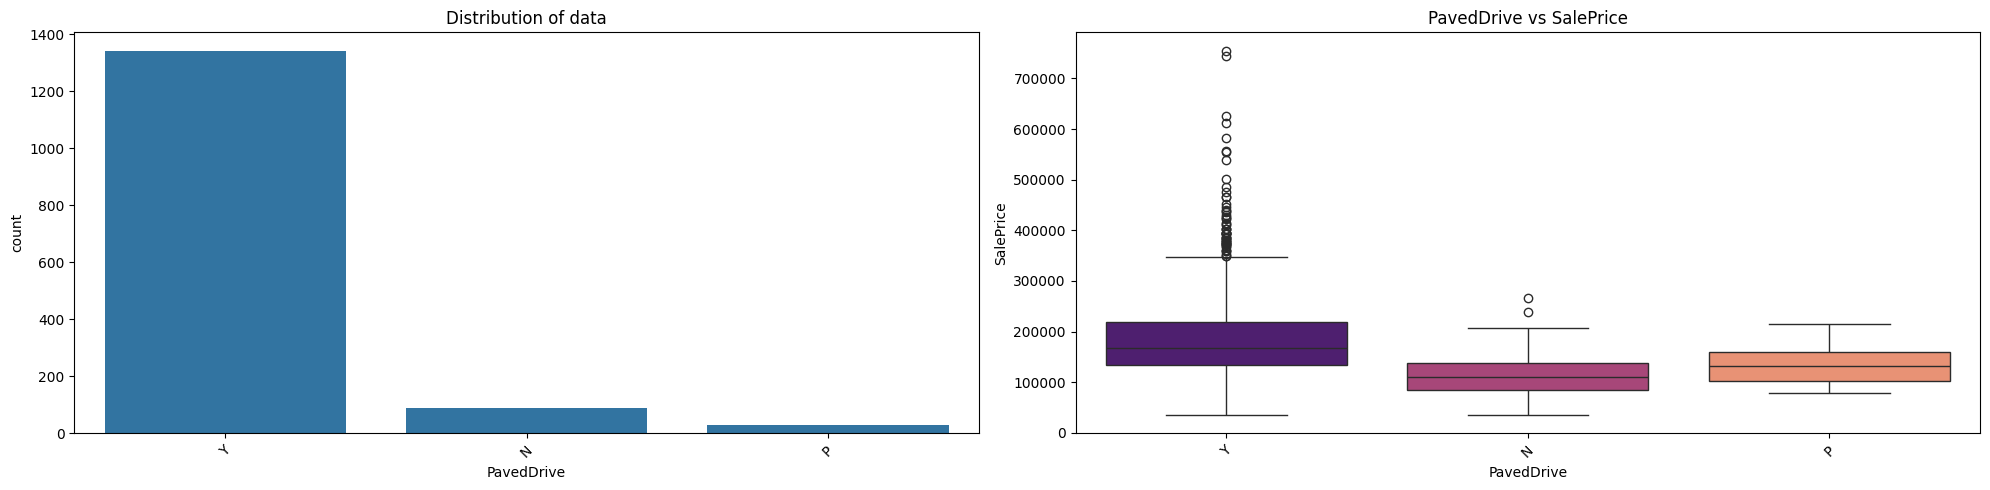

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


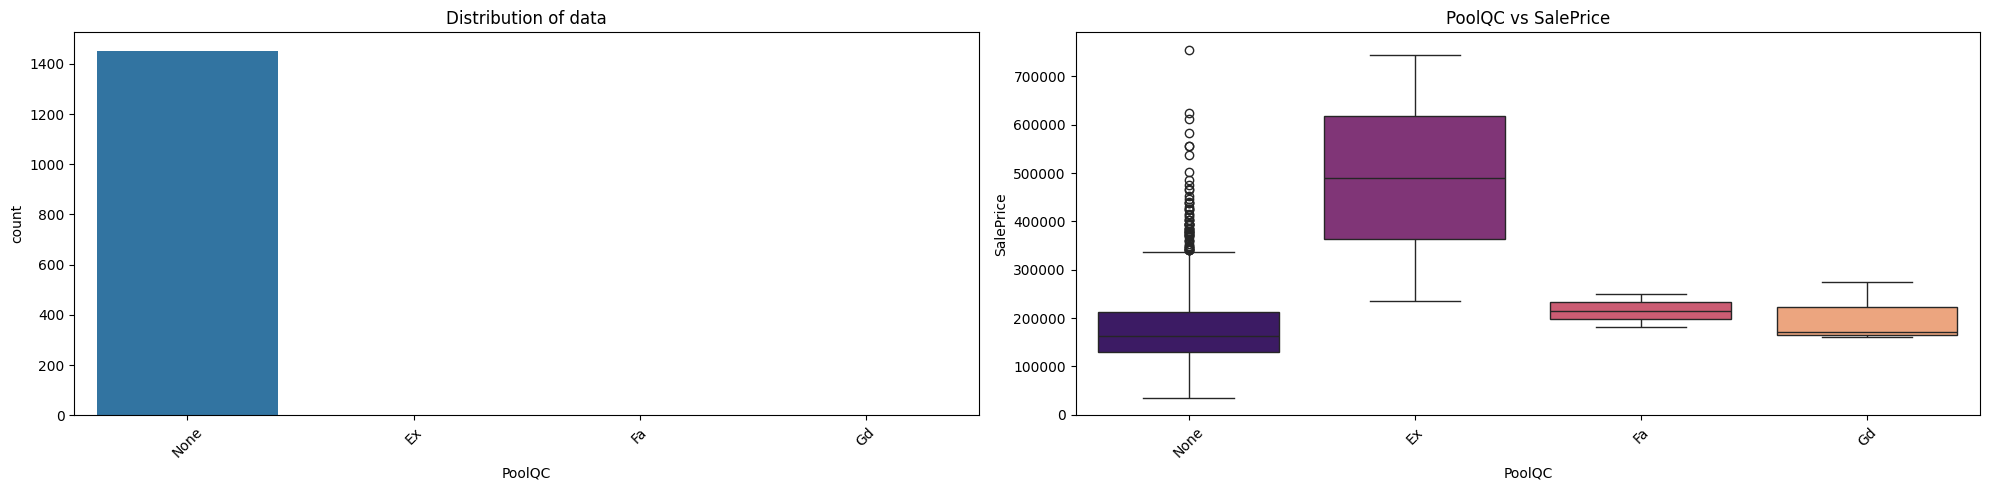

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


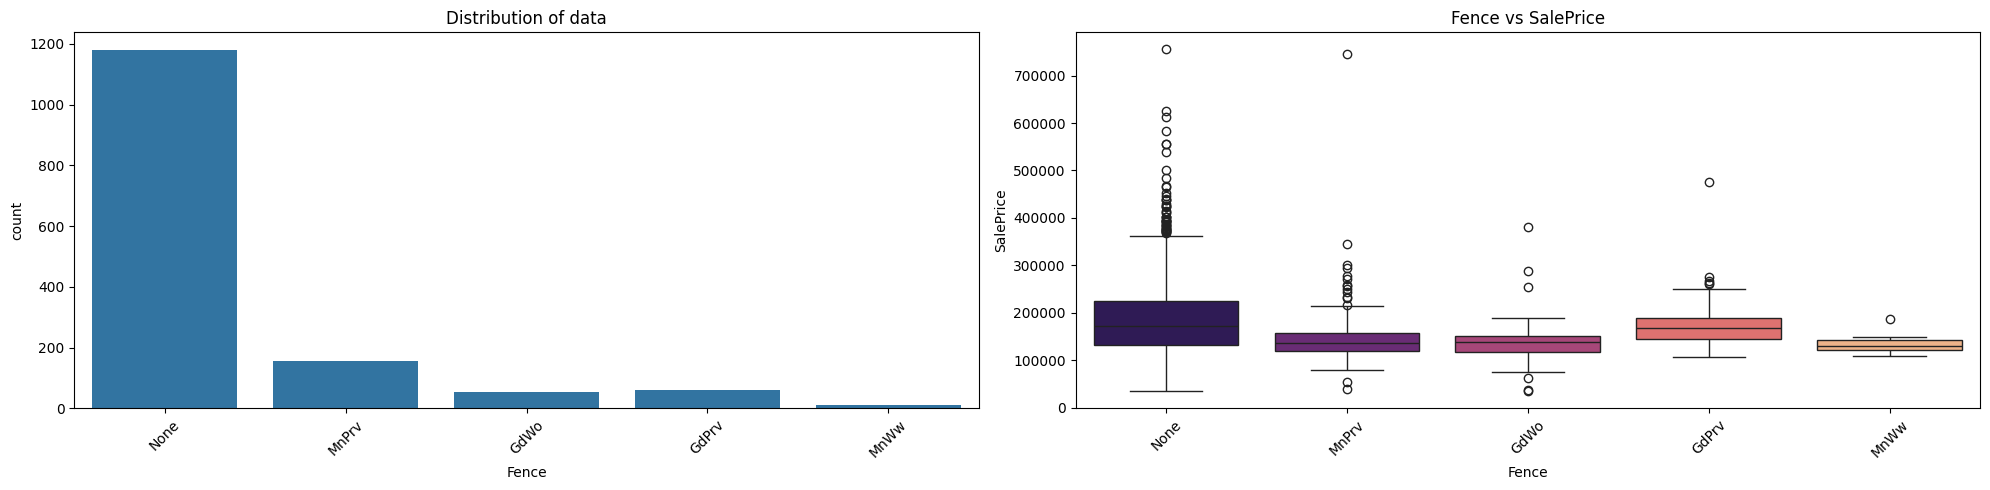

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


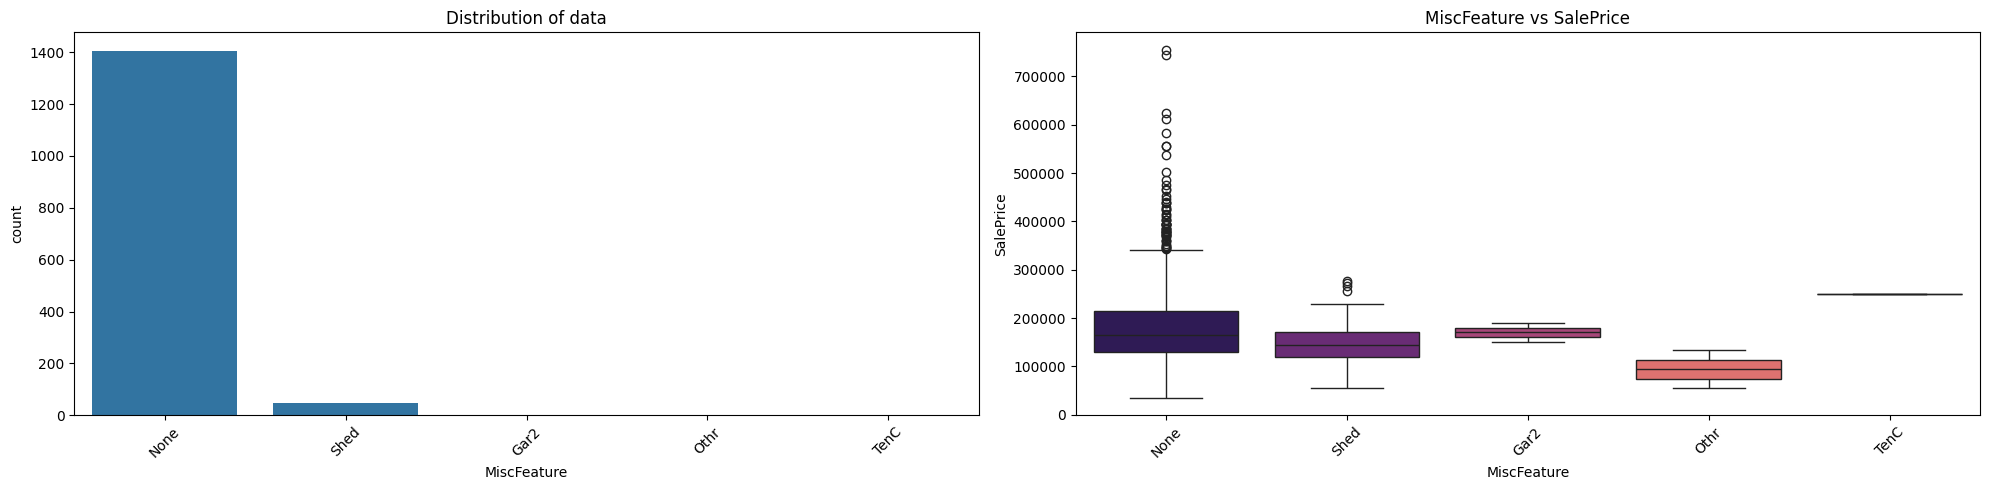

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


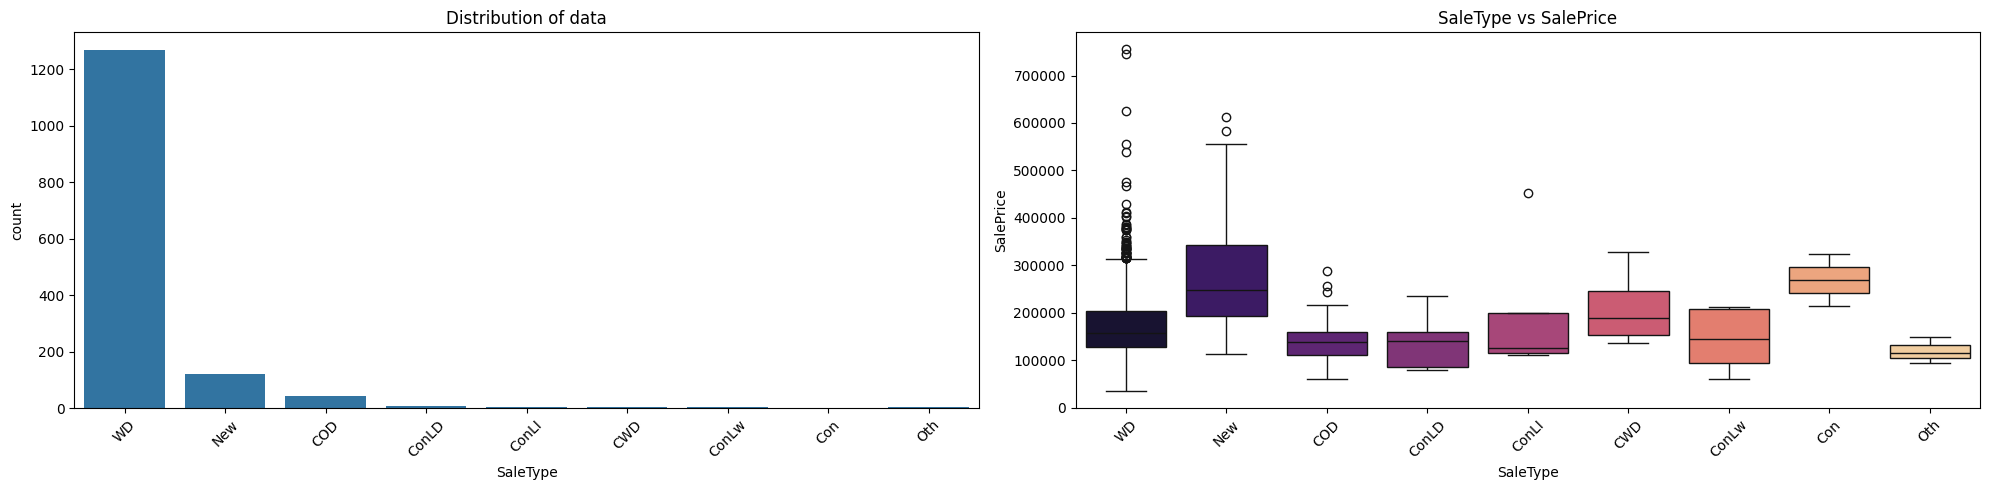

C:\Users\hp\AppData\Local\Temp\ipykernel_6176\3069701300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')


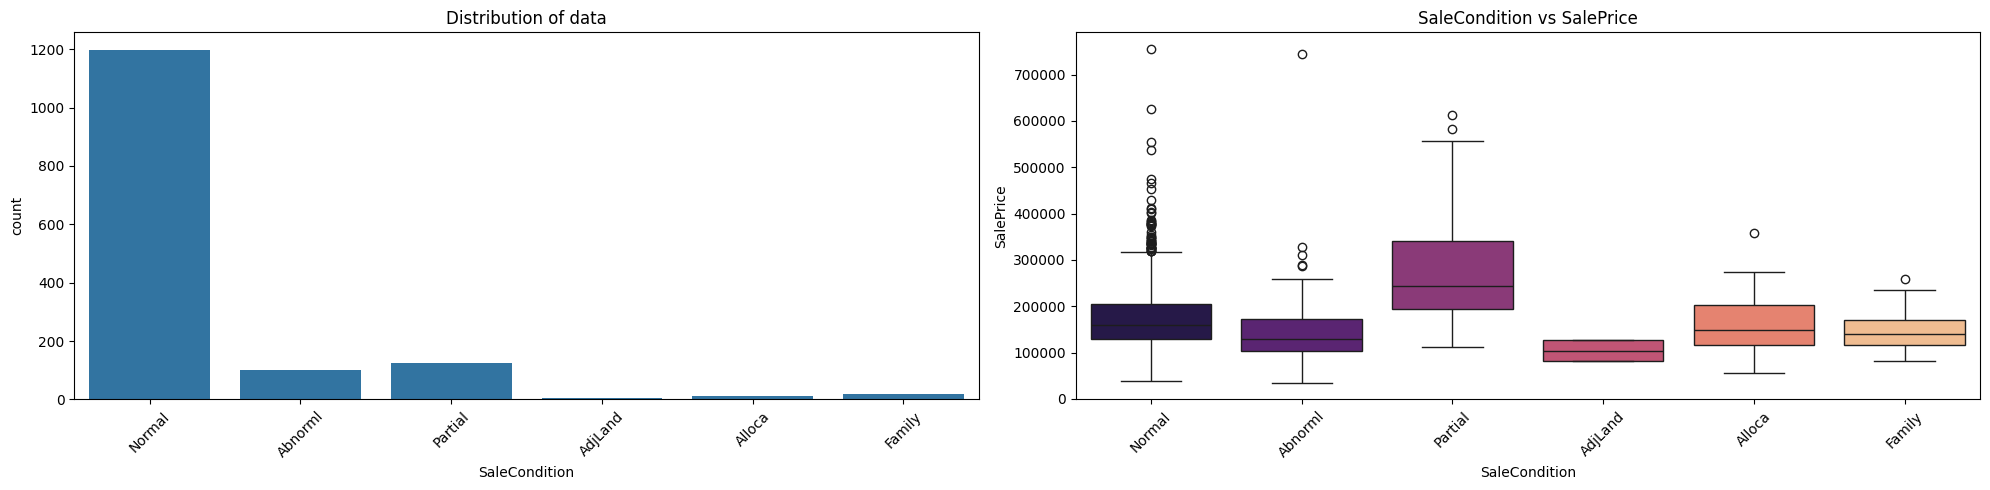

In [82]:
feature_cols = df.select_dtypes(include = ['object']).columns

for feature in feature_cols:
    fig, ax = plt.subplots(1, 2, figsize = (20,5))

    sns.countplot(x = df[feature], ax= ax[0])
    ax[0].set_title('Distribution of data')
    ax[0].tick_params(axis='x', rotation=45)

    sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1], palette='magma')
    ax[1].set_title(f'{feature} vs SalePrice')
    ax[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

In [83]:
df.drop(['BsmtFinType2', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageQual', 'GarageCond', 'PavedDrive'], axis = 1, inplace = True)

In [84]:
df.drop(['PoolQC', 'Fence','MiscFeature', 'SaleType', 'SaleCondition'], axis = 1, inplace = True)

Therefore, all the categorical variables not contributing to saleprice are dropped from the database. Lets take a look at the data: 

In [85]:
df.head(10)

,MSSubClass,MSZoning,LotFrontage,LotArea,Neighborhood,HouseStyle,OverallQual,YearBuilt,YearRemodAdd,Exterior1st,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,Log_SalePrice
0,60,RL,65.000000,8450,CollgCr,2Story,7,2003,2003,VinylSd,...,61,0,0,0,0,0,2,2008,208500,12.247699
1,20,RL,80.000000,9600,Veenker,1Story,6,1976,1976,MetalSd,...,0,0,0,0,0,0,5,2007,181500,12.109016
2,60,RL,68.000000,11250,CollgCr,2Story,7,2001,2002,VinylSd,...,42,0,0,0,0,0,9,2008,223500,12.317171
3,70,RL,60.000000,9550,Crawfor,2Story,7,1915,1970,Wd Sdng,...,35,272,0,0,0,0,2,2006,140000,11.849405
4,60,RL,84.000000,14260,NoRidge,2Story,8,2000,2000,VinylSd,...,84,0,0,0,0,0,12,2008,250000,12.429220
5,50,RL,85.000000,14115,Mitchel,1.5Fin,5,1993,1995,VinylSd,...,30,0,320,0,0,700,10,2009,143000,11.870607
6,20,RL,75.000000,10084,Somerst,1Story,8,2004,2005,VinylSd,...,57,0,0,0,0,0,8,2007,307000,12.634606
7,60,RL,70.049958,10382,NWAmes,2Story,7,1973,1973,HdBoard,...,204,228,0,0,0,350,11,2009,200000,12.206078
8,50,RM,51.000000,6120,OldTown,1.5Fin,7,1931,1950,BrkFace,...,0,205,0,0,0,0,4,2008,129900,11.774528
9,190,RL,50.000000,7420,BrkSide,1.5Unf,5,1939,1950,MetalSd,...,4,0,0,0,0,0,1,2008,118000,11.678448


Now using one hot encoding we will try to convert the categorical variables into numerical ones 

In [86]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

target = ['SalePrice', 'Log_SalePrice']
numeric_cols = df.select_dtypes(exclude = ['object']).columns
feature_numeric_cols = [col for col in numeric_cols if col not in target]
feature_cols = df.select_dtypes(include = ['object']).columns
preprocess = ColumnTransformer(transformers = [
                               ('num', StandardScaler(), feature_numeric_cols),('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), feature_cols)])

X = preprocess.fit_transform(df)
names = preprocess.get_feature_names_out()

In [87]:
df1 = pd.DataFrame(X, columns = names, index = df.index)
df1.head(10)

,num__MSSubClass,num__LotFrontage,num__LotArea,num__OverallQual,num__YearBuilt,num__YearRemodAdd,num__MasVnrArea,num__BsmtFinSF1,num__BsmtFinSF2,num__BsmtUnfSF,...,cat__FireplaceQu_TA,cat__GarageType_Attchd,cat__GarageType_Basment,cat__GarageType_BuiltIn,cat__GarageType_CarPort,cat__GarageType_Detchd,cat__GarageType_None,cat__GarageFinish_None,cat__GarageFinish_RFn,cat__GarageFinish_Unf
0,0.073375,-2.293718e-01,-0.207142,0.651479,1.050994,0.878668,0.514104,0.575425,-0.288653,-0.944591,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.872563,4.519361e-01,-0.091886,-0.071836,0.156734,-0.429577,-0.570750,1.171992,-0.288653,-0.641228,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.073375,-9.311018e-02,0.073480,0.651479,0.984752,0.830215,0.325915,0.092907,-0.288653,-0.301643,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.309859,-4.564744e-01,-0.096897,0.651479,-1.863632,-0.720298,-0.570750,-0.499274,-0.288653,-0.061670,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.073375,6.336182e-01,0.375148,1.374795,0.951632,0.733308,1.366489,0.463568,-0.288653,-0.174865,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,-0.163109,6.790387e-01,0.360616,-0.795151,0.719786,0.491040,-0.570750,0.632450,-0.288653,-1.139286,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6,-0.872563,2.248335e-01,-0.043379,1.374795,1.084115,0.975575,0.458754,2.029558,-0.288653,-0.566519,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,0.073375,6.454645e-16,-0.013513,0.651479,0.057371,-0.574938,0.757643,0.910994,-0.090220,-0.795173,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8,-0.163109,-8.652591e-01,-0.440659,0.651479,-1.333700,-1.689368,-0.570750,-0.973018,-0.288653,0.871057,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
9,3.147673,-9.106796e-01,-0.310370,-0.795151,-1.068734,-1.689368,-0.570750,0.893448,-0.288653,-0.967230,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [88]:
df_final = pd.concat([df1, df[['Log_SalePrice']]], axis=1)

In [89]:
df_final.head()

,num__MSSubClass,num__LotFrontage,num__LotArea,num__OverallQual,num__YearBuilt,num__YearRemodAdd,num__MasVnrArea,num__BsmtFinSF1,num__BsmtFinSF2,num__BsmtUnfSF,...,cat__GarageType_Attchd,cat__GarageType_Basment,cat__GarageType_BuiltIn,cat__GarageType_CarPort,cat__GarageType_Detchd,cat__GarageType_None,cat__GarageFinish_None,cat__GarageFinish_RFn,cat__GarageFinish_Unf,Log_SalePrice
0,0.073375,-0.229372,-0.207142,0.651479,1.050994,0.878668,0.514104,0.575425,-0.288653,-0.944591,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,12.247699
1,-0.872563,0.451936,-0.091886,-0.071836,0.156734,-0.429577,-0.570750,1.171992,-0.288653,-0.641228,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,12.109016
2,0.073375,-0.093110,0.073480,0.651479,0.984752,0.830215,0.325915,0.092907,-0.288653,-0.301643,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,12.317171
3,0.309859,-0.456474,-0.096897,0.651479,-1.863632,-0.720298,-0.570750,-0.499274,-0.288653,-0.061670,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,11.849405
4,0.073375,0.633618,0.375148,1.374795,0.951632,0.733308,1.366489,0.463568,-0.288653,-0.174865,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,12.429220


<Axes: >

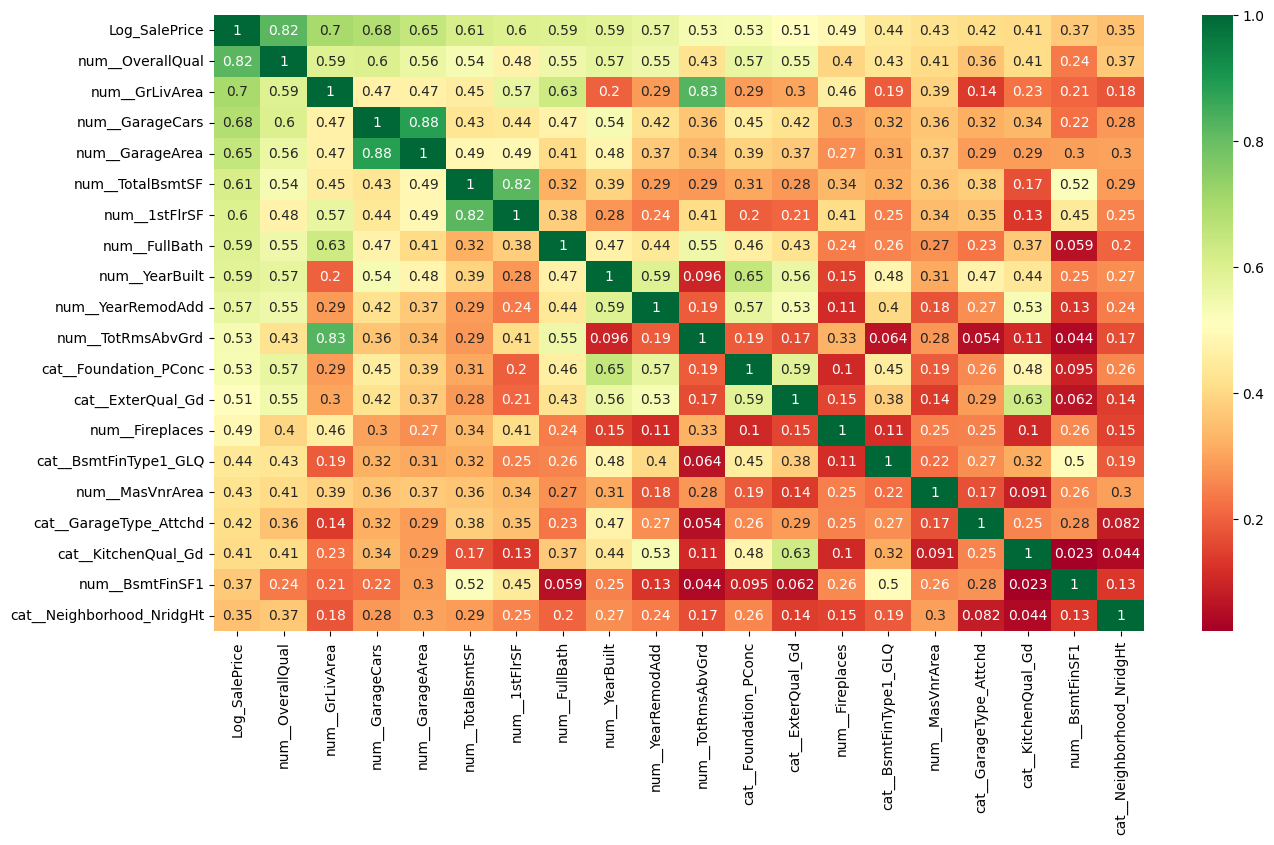

In [90]:
cols = df_final.corr()['Log_SalePrice'].sort_values(ascending=False).head(20).index #checking correlation with sale price
plt.figure(figsize=(15, 8))
sns.heatmap(df_final[cols].corr(), annot=True, cmap='RdYlGn')# checking collinearity

Looking at your heatmap, there are several "red flag" pairs where two independent variables are so highly correlated that they provide redundant information. Keeping both can make a linear model unstable.  we are looking for dark green squares outside the diagonal and will remove one of the columns from our database

In [91]:
df_final.drop(['num__GarageArea', 'num__1stFlrSF', 'num__TotRmsAbvGrd'], axis= 1, inplace = True)

### Data Splitting

Now we will split the data into training and test data. Then we will train our regression model to predict the price of house

In [92]:
y_data = df_final.iloc[:,-1:]
x_data = df_final.iloc[:, :-1]

In [93]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, random_state = 43)

We will try multiple regression models such as linear, ridge, lasso. Starting with Linear: 

## Linear Regression Analysis

In [94]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

Input = [('pf', PolynomialFeatures(degree = 2)),('lr', LinearRegression())]
pipe = Pipeline(Input)
pipe.fit(x_train, y_train)
yhat= pipe.predict(x_test)

In [95]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, yhat)
mse

0.06903321252457109

In [96]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, yhat)
r2

0.6058369100770042

<Axes: xlabel='Log_SalePrice', ylabel='Log_SalePrice'>

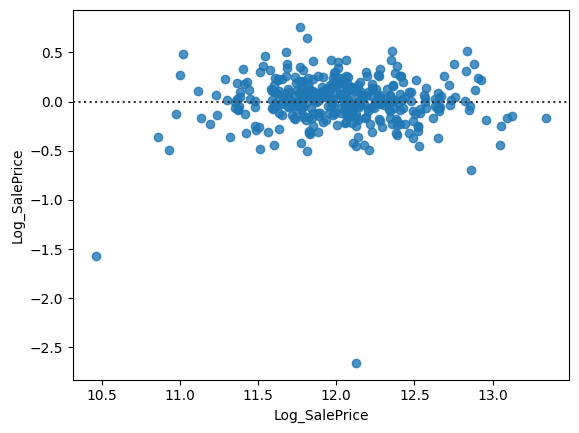

In [97]:
sns.residplot(x = y_test, y = (y_test - yhat))

This means there are some outliers which are poisoning our model as our model is not able to predict the price for them so first we have to remove them and then again try to retrain our model

In [98]:
Q1 = df_final['Log_SalePrice'].quantile(0.25)
Q3 = df_final['Log_SalePrice'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_final[(df_final['Log_SalePrice'] < lower_bound) | (df_final['Log_SalePrice'] > upper_bound)]
print(outliers)

      num__MSSubClass  num__LotFrontage  num__LotArea  num__OverallQual  \
30           0.309859     -9.106796e-01     -0.202131         -1.518467   
178         -0.872563     -3.202128e-01      0.692151          2.098110   
185          0.428102      9.061413e-01      1.246078          2.821425   
375         -0.636078      6.454645e-16     -0.049793         -3.688413   
410         -0.872563     -9.311018e-02     -0.094793         -0.795151   
440         -0.872563      1.587449e+00      0.492508          2.821425   
495         -0.636078     -4.564744e-01     -0.264368         -1.518467   
533         -0.872563     -9.106796e-01     -0.552908         -3.688413   
636         -0.636078     -8.652591e-01     -0.440659         -2.965098   
691          0.073375      1.542029e+00      1.104264          2.821425   
705          3.147673     -2.269135e-03     -0.492774         -1.518467   
710         -0.636078     -6.381565e-01     -0.640101         -2.241782   
769          0.073375    

we found 28 rows which act as outliers in our data and therefore theese needs to be removed from our model

In [99]:
df_final = df_final.drop(outliers.index)

y_data = df_final.iloc[:,-1:]
x_data = df_final.iloc[:, :-1]

In [100]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, random_state = 43)

Input = [('pf', PolynomialFeatures(degree = 2)),('lr', LinearRegression())]
pipe1 = Pipeline(Input)
pipe.fit(x_train, y_train)
yhat= pipe.predict(x_test)
r2 = r2_score(y_test, yhat)
r2

0.704448705581562

There is a jump from 0.6 to 0.7 that means the outliers were confusing the model.


<Axes: xlabel='Log_SalePrice', ylabel='Log_SalePrice'>

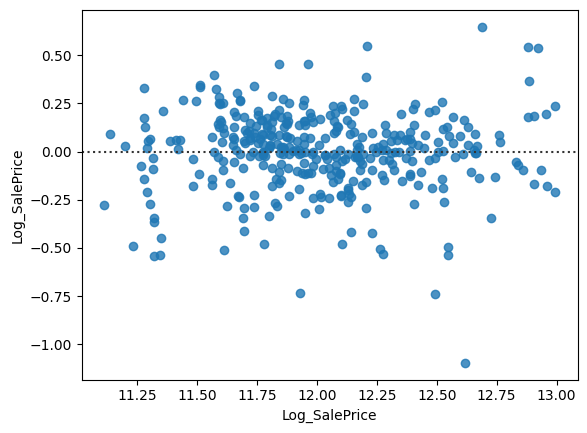

In [101]:
sns.residplot(x = y_test, y = (y_test-yhat))

Now the residual plot is more generalized and randomly distributed. Now to improve the model's ability to predict outcome on new, unseen data. We will use cross validation. 

In [102]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipe1, x_data, y_data, cv =4, scoring = 'r2')
scores.mean()


0.6415460499094556

This gives the clear picture that linear regression is unable to handle the complexity of data here. so we will move on to our next model

## Lasso Regression


In [103]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso

In [105]:
Input = [('PF',PolynomialFeatures()),('model',Lasso(max_iter=10000))]
params = {'PF__degree':[1], 'model__alpha':np.geomspace(1e-6, 1e4, 20)}

pipe_las = Pipeline(Input)

grid = GridSearchCV(pipe_las, params, cv= 4, n_jobs=-1, verbose=1)
grid.fit(x_train, y_train)
grid.best_score_

Fitting 4 folds for each of 20 candidates, totalling 80 fits


0.8401697121190504

In [106]:
grid.best_params_

{'PF__degree': 1, 'model__alpha': 0.0004281332398719391}

In [ ]:
yhat_las = grid.predict(x_test)
r2_las = r2_score(y_test, yhat_las)               
r2_las

0.890241461362287

We observed that lasso regression achieved a great success in predicting the target variable with R^2 score of 0.89 and alpha of 0.0004 and polynomial_degree of 1

Let's start with ridge regression

## Ridge regression

In [110]:
from sklearn.linear_model import Ridge
Input = [('PF',PolynomialFeatures()),('model',Ridge())]
params = {'PF__degree':[1], 'model__alpha':np.geomspace(1e-6, 1e4, 20)}

pipe_ridge = Pipeline(Input)

grid1 = GridSearchCV(pipe_ridge, params, cv = 4)
grid1.fit(x_train, y_train)
yhat_ridge = grid1.predict(x_test)

r2_ridge = r2_score(y_test, yhat_ridge)
r2_ridge

0.8882152982420252

In conclusion, Lasso works best for this dataset.